# EVT/POT Calibration Workflow (GloFAS v4 → Virtual Gauges → Poisson λ)

This notebook provides an **end-to-end, operator-friendly calibration workflow** for riverine flood triggers:

1. **Select impact units (HydroBASINS L12)**
   - **Mode A** (municipality AOI): population-weighted centroid (WorldPop) + 5 km geodesic buffer, clipped to ADM3
   - **Mode B** (context basin): select all L12 inside a configured context basin polygon (e.g., L7)
2. **Assign virtual gauges**
   - One representative point per L12: **L12 pour point → nearest GloFAS grid cell**
   - **Collisions are expected** (multiple L12 → same GloFAS cell). We calibrate **per unique cell**.
3. **GRIB → daily discharge time series** (cached)
4. **POT/EVT extraction** using `pyextremes` + run-length declustering
5. **Poisson frequency λ** per unique virtual gauge

> Locked decisions: all geometry remains in **EPSG:4326 (WGS84)** and we use **GloFAS historical/reanalysis v4 consolidated discharge GRIBs**.


## 0) Setup (robust imports, repo root, dependency checks)

This cell makes the notebook robust to:
- `ModuleNotFoundError` when running from different working directories
- Windows path handling (use raw strings)

If anything fails here, fix it before proceeding.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import psutil
from pathlib import Path

# Optional interactivity
try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
    print('HAS_WIDGETS:', HAS_WIDGETS)
except Exception:
    HAS_WIDGETS = False
    print('HAS_WIDGETS:', HAS_WIDGETS)

# --- Find repo root and add src/ to sys.path ---
try:
    from philflood.utils.paths import find_repo_root, ensure_src_on_path
except Exception:
    # Fallback: assume this notebook lives under <repo>/notebooks/
    def find_repo_root(start=None):
        p = Path.cwd().resolve() if start is None else Path(start).resolve()
        for parent in (p, *p.parents):
            if (parent / 'src').exists():
                return parent
        raise RuntimeError('Could not find repo root; set REPO_ROOT manually')

    def ensure_src_on_path(repo_root):
        repo_root = Path(repo_root).resolve()
        src = repo_root / 'src'
        if str(src) not in sys.path:
            sys.path.insert(0, str(src))
        return src

REPO_ROOT = find_repo_root()
SRC_PATH = ensure_src_on_path(REPO_ROOT)
print('REPO_ROOT:', REPO_ROOT)
print('SRC_PATH :', SRC_PATH)

# Now imports from src/
from philflood.config.basin import load_basin_config
from philflood.geo.worldpop import population_weighted_centroid
from philflood.geo.aoi import build_municipality_aoi
from philflood.geo.hydrobasins import read_vector, select_context_polygon, select_l12_by_geometry, get_id_field
from philflood.adapters.glofas_grib_v4 import (
    discover_grib_year_files,
    open_grib_dataset,
    nearest_grid_cell,
    load_or_build_gauge_timeseries,
)
from philflood.qc.timeseries import qc_daily_series, qc_summary_dict
from philflood.calibration.evt_pot import pot_extract, fit_gpd_to_pot

print('Core imports OK')


HAS_WIDGETS: True
REPO_ROOT: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL
SRC_PATH : C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\src
Core imports OK


In [2]:
# === Section 0 (after all imports, before operator inputs) ===

# --- Clean Progress Logging ---
class ProgressLogger:
    """Structured progress reporting without noise."""
    
    def __init__(self, name):
        self.name = name
    
    def section(self, title):
        """Print a clean section header."""
        print(f"\n{'='*70}")
        print(f"  {title}")
        print(f"{'='*70}")
    
    def step(self, message, status="•"):
        """Print a single step."""
        print(f"{status} {message}")
    
    def success(self, message):
        """Print a success message."""
        print(f"✓ {message}")
    
    def warn(self, message):
        """Print a warning."""
        print(f"⚠️  {message}")
    
    def error(self, message):
        """Print an error."""
        print(f"✗ {message}")
    
    def table(self, title, data_dict):
        """Print a simple key-value table."""
        print(f"\n{title}:")
        for key, value in data_dict.items():
            print(f"  {key:.<40} {value}")
    
    def progress(self, current, total, prefix="", suffix=""):
        """Print progress every 10% (no spam)."""
        if current % max(1, total // 10) == 0 or current == total:
            pct = int(100 * current / total)
            print(f"  [{pct:3d}%] {current}/{total} {prefix} {suffix}")

# Initialize global logger
log = ProgressLogger("EVT/POT Calibration")
log.step("Logger initialized")


• Logger initialized


## 1) Operator inputs (edit here)

Set paths and mode switches below. The notebook will validate and **fail fast** if anything is missing.

**Locked data paths (examples):**
- WorldPop raster: `C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\worldpop\PHL\phl_pop_2025_CN_100m_R2025A_v1.tif`
- ADM3 municipalities: `C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\admin\phl_cod_ab\phl_adm3.geojson`
- HydroBASINS L12 polygons: `C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\hydrobasins\australasia\hybas_au_lev01-12_v1c\hybas_au_lev12_v1c.shp`
- HydroBASINS L12 pour points: `C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\hydrobasins\australasia\hybas_pour_lev01-12_v1_shp\hybas_pour_lev12_v1.shp`
- GloFAS v4 GRIB root: `C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\glofas\historical\version_4_0\consolidated\discharge\grib2\area_35_63_4_131`

> Tip: use raw strings `r"..."` on Windows.


In [3]:
# --- Mode toggles (locked requirement) ---
USE_MUNI_AOI = False  # True = municipality AOI mode, False = context basin mode
USE_CELL_EXTRACTION = True  # True = cell-level extraction (all grid cells within basin polygon), False = pour point extraction

# --- Setup logging (suppress library chatter, let ProgressLogger handle output) ---
from datetime import datetime
import logging
logging.basicConfig(
    level=logging.WARNING,  # Suppress INFO/DEBUG chatter from libraries
    format='%(levelname)s: %(message)s'
)
logging.getLogger('philflood').setLevel(logging.WARNING)

log.section("SECTION 1: Operator Configuration")

# --- Municipality AOI mode inputs ---
adm3_ids = [
    # Example: "PHLxxxx". Must match adm3_id in the ADM3 GeoJSON.
    # Fill with one or more municipalities.
    "30758251B93060635103686",  # Gattaran, Cagayan

]
aoi_buffer_km = 5

# --- Context basin mode inputs (legacy YAML) ---
basin_cfg_relpath = r"ops\configs\basins\Cagayan_01.yaml"  # repo-relative (legacy)
context_select_mode = "within"  # within|intersects

# --- Locked data paths (set these to your local repo paths) ---
worldpop_raster = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\worldpop\PHL\phl_pop_2025_CN_100m_R2025A_v1.tif")
adm3_geojson = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\admin\phl_cod_ab\phl_adm3.geojson")
hybas_l12_shp = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\hydrobasins\australasia\hybas_au_lev01-12_v1c\hybas_au_lev12_v1c.shp")
hybas_pour_l12_shp = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\hydrobasins\australasia\hybas_pour_lev01-12_v1_shp\hybas_pour_lev12_v1.shp")

glofas_grib_root = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\glofas\historical\version_4_0\consolidated\discharge\grib2\area_35_63_4_131")

# --- Calibration defaults ---
run_tag = "2026-01-19_calib-test"  # used in output folder names
#run_tag = datetime.now(timezone.utc).strftime("%Y-%m-%d_%H%M_UTC") # Production timestamp
analyst_name = "David"

run_length_days = 5
candidate_quantiles = [0.90, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]

# Optional: explicitly set discharge variable name in GRIB (leave None to auto-detect)
discharge_var = None

# --- Processed output root (repo-relative) ---
processed_root = REPO_ROOT / "data" / "processed"

log.table("Configuration Summary", {
    "Mode": "Municipality AOI" if USE_MUNI_AOI else "Context basin",
    "Extraction method": "Cell-level" if USE_CELL_EXTRACTION else "Pour point",
    "Run tag": run_tag,
    "Output root": str(processed_root),
    "Analyst": analyst_name,
})
log.success("Operator configuration loaded")


  SECTION 1: Operator Configuration

Configuration Summary:
  Mode.................................... Context basin
  Extraction method....................... Cell-level
  Run tag................................. 2026-01-19_calib-test
  Output root............................. C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed
  Analyst................................. David
✓ Operator configuration loaded


In [4]:
# --- Year selector for debugging (test individual years) ---
# Set to None to process all available years, or provide a list like [2014] to test specific years
# USAGE: To test if 2014 is problematic, set: SELECTED_YEARS = [2014]
#        To test a range like 2010-2015: SELECTED_YEARS = list(range(2010, 2016))
#        To process all years: SELECTED_YEARS = None
SELECTED_YEARS = None #list(range(2012, 2017))  # Examples: None (all), [2014], [2010, 2011, 2012], list(range(2010, 2016))

log.section("SECTION 2: Year Selection")
if SELECTED_YEARS is None:
    log.success("Processing ALL available years (1979-2025)")
else:
    log.warn(f"Year filtering enabled: {SELECTED_YEARS}")
    log.step(f"Will process {len(SELECTED_YEARS)} years")


  SECTION 2: Year Selection
✓ Processing ALL available years (1979-2025)


## 2) Validate inputs (fail fast)

We stop early if any required file is missing. This prevents silent downstream failures.


In [5]:
log.section("SECTION 2B: Validate Inputs")
log.step("Checking required files...")

def _assert_exists(p: Path, label: str):
    if not p.exists():
        log.error(f"{label} not found: {p}")
        raise FileNotFoundError(f"{label} not found: {p}")

_assert_exists(worldpop_raster, "WorldPop raster")
_assert_exists(adm3_geojson, "ADM3 GeoJSON")
_assert_exists(hybas_l12_shp, "HydroBASINS L12 polygons")
_assert_exists(hybas_pour_l12_shp, "HydroBASINS L12 pour points")
_assert_exists(glofas_grib_root, "GloFAS GRIB root")

# Context basin YAML is only required in context mode
if not USE_MUNI_AOI:
    basin_cfg_path = (REPO_ROOT / Path(basin_cfg_relpath)).resolve()
    _assert_exists(basin_cfg_path, "Legacy basin config YAML")

log.success("All required inputs exist")


  SECTION 2B: Validate Inputs
• Checking required files...
✓ All required inputs exist


## 3) Load vectors and (optionally) context basin config


In [6]:
import geopandas as gpd

log.section("SECTION 3: Loading Vector Data")

adm3_gdf = read_vector(adm3_geojson)
l12_gdf = read_vector(hybas_l12_shp)
pour_gdf = read_vector(hybas_pour_l12_shp)

log.table("Vector Counts", {
    "ADM3 (municipalities)": len(adm3_gdf),
    "L12 (basins)": len(l12_gdf),
    "Pour points": len(pour_gdf),
})

adm3_id_field = "adm3_id" if "adm3_id" in adm3_gdf.columns else None
if adm3_id_field is None:
    log.error("ADM3 must have 'adm3_id' column")
    raise KeyError("Missing adm3_id")

l12_id_field = get_id_field(l12_gdf)
pour_id_field = get_id_field(pour_gdf)

log.success("All vectors loaded")

basin_cfg = None
context_gdf = None
context_geom = None

if not USE_MUNI_AOI:
    log.step("Context basin mode: Loading basin config...")
    basin_cfg = load_basin_config(basin_cfg_path)
    log.step(f"Basin: {basin_cfg.basin_id} | HydroBASINS Level: {basin_cfg.hydrobasins_level}")
    
    # Dynamic HydroBASINS level loading 
    target_level = int(basin_cfg.hydrobasins_level)
    
    if target_level == 12:
        context_gdf = l12_gdf
        log.step(f"Using pre-loaded L12 shapefile: {len(context_gdf)} polygons")
    else:
        level_str = f"{target_level:02d}"
        hybas_parent = hybas_l12_shp.parent
        hybas_dynamic = hybas_parent / f"hybas_au_lev{level_str}_v1c.shp"
        
        if not hybas_dynamic.exists():
            log.error(f"HydroBASINS level {target_level} not found: {hybas_dynamic}")
            raise FileNotFoundError(
                f"HydroBASINS level {target_level} shapefile not found at:\n"
                f"  {hybas_dynamic}\n"
                f"Expected naming: hybas_au_lev{level_str}_v1c.shp\n"
                f"Available files in {hybas_parent}:\n"
                f"  {list(hybas_parent.glob('hybas_au_lev*.shp'))}"
            )
        
        context_gdf = read_vector(hybas_dynamic)
        
        if context_gdf.empty or context_gdf.geometry.isna().all():
            log.error(f"Loaded shapefile is invalid: {hybas_dynamic}")
            raise ValueError(f"Loaded shapefile is invalid: {hybas_dynamic}")
        
        log.step(f"Loaded HydroBASINS level {target_level}: {len(context_gdf)} polygons")
    
    log.success(f"Context basin ready: {len(context_gdf)} polygons")


  SECTION 3: Loading Vector Data

Vector Counts:
  ADM3 (municipalities)................... 1647
  L12 (basins)............................ 83929
  Pour points............................. 5271492
✓ All vectors loaded
• Context basin mode: Loading basin config...
• Basin: Cagayan_01 | HydroBASINS Level: 7
• Loaded HydroBASINS level 7: 4670 polygons
✓ Context basin ready: 4670 polygons


## 4) Select L12 impact units

Two modes:

### Mode A: Municipality AOI
- For each selected municipality:
  - population-weighted centroid (WorldPop)
  - AOI = geodesic buffer(5 km) clipped to municipality polygon
  - select all intersecting L12 polygons

### Mode B: Context basin
- Select all L12 polygons inside the context basin geometry


In [7]:
log.section("SECTION 4: Select L12 Impact Units")

selected_l12 = None
muni_aoi_records = []
aoi_geoms = []

if USE_MUNI_AOI:
    if not adm3_ids:
        log.error("USE_MUNI_AOI=True requires adm3_ids to be provided")
        raise ValueError("USE_MUNI_AOI=True requires adm3_ids to be provided")
    
    log.step(f"Processing {len(adm3_ids)} municipality/municipalities with {aoi_buffer_km} km buffer...")

    for mid in adm3_ids:
        muni = adm3_gdf[adm3_gdf[adm3_id_field] == mid]
        if len(muni) != 1:
            raise ValueError(f"Expected exactly 1 municipality for adm3_id={mid}, found {len(muni)}")
        muni_geom = muni.geometry.values[0]

        # Population-weighted centroid (fails loudly if no population)
        wc = population_weighted_centroid(muni_geom, worldpop_raster, top_n_pixels=3)
        aoi = build_municipality_aoi(muni_geom, wc.point, buffer_km=aoi_buffer_km)

        aoi_geoms.append(aoi.aoi_polygon)

        sel = select_l12_by_geometry(l12_gdf, aoi.aoi_polygon, mode="intersects")
        muni_aoi_records.append({
            "adm3_id": mid,
            "centroid_lon": float(wc.point.x),
            "centroid_lat": float(wc.point.y),
            "total_population": float(wc.total_population),
            "valid_pixel_count": int(wc.valid_pixel_count),
            "n_l12_selected": int(len(sel)),
            "l12_ids": sel[l12_id_field].astype(int).tolist(),
        })
        log.step(f"  {mid}: {len(sel)} L12 basins, pop={wc.total_population:.0f}")

    # Union selection across municipalities
    all_ids = sorted({i for r in muni_aoi_records for i in r["l12_ids"]})
    selected_l12 = l12_gdf[l12_gdf[l12_id_field].astype(int).isin(all_ids)].copy()

else:
    # Context basin mode
    log.step("Context basin mode: Selecting L12 by geometry...")
    context_sel = select_context_polygon(context_gdf, basin_cfg.hydrobasins_id)
    context_geom = context_sel.geometry.values[0]
    selected_l12 = select_l12_by_geometry(l12_gdf, context_geom, mode=context_select_mode)
    log.step(f"Selected {len(selected_l12)} L12 basins")

log.success(f"Section 4 complete: {len(selected_l12)} L12 basins selected")


  SECTION 4: Select L12 Impact Units
• Context basin mode: Selecting L12 by geometry...
• Selected 36 L12 basins
✓ Section 4 complete: 36 L12 basins selected


## 5) Build virtual gauges (L12 pour point → nearest GloFAS grid cell)

Locked decisions:
- **One representative discharge point per selected L12** = its L12 pour point
- Map to **nearest GloFAS v4 grid cell**
- If multiple L12 map to the same cell: **expected**. We calibrate per **unique cell**.

We also guard against a common xarray pitfall: `.sel(method='nearest')` can snap points even if the input point is outside the dataset extent (so we check bounds first).


In [8]:
log.section("SECTION 5: Build Virtual Gauges")

# Join selected L12 to pour points
log.step("Building L12→GloFAS cell mapping...")

# Discover GRIB inventory for grid access
log.step("Discovering GloFAS GRIB inventory...")
inventory = discover_grib_year_files(glofas_grib_root, selected_years=SELECTED_YEARS)
log.step(f"Discovered {len(inventory)} yearly GRIBs: {inventory[0].year}..{inventory[-1].year}")

if USE_CELL_EXTRACTION:
    # ========== CELL-LEVEL EXTRACTION ==========
    log.step("MODE: Cell-level extraction (all cells within L12 polygons)")
    
    # Open one GRIB to access grid structure
    sample_grib = inventory[0].grib_path
    index_dir = processed_root / "glofas" / "v4" / "area_35_63_4_131" / "_cfgrib_index"
    ds = open_grib_dataset(sample_grib, index_dir=index_dir)
    
    from philflood.adapters.glofas_grib_v4 import cells_within_polygon
    
    # For each L12 polygon, find all intersecting grid cells
    cell_records = []
    for l12_id, l12_geom in zip(selected_l12[l12_id_field], selected_l12.geometry):
        cells_df = cells_within_polygon(ds, l12_geom)
        if cells_df.empty:
            log.warn(f"L12 {l12_id}: no GloFAS cells found within polygon")
            continue
        cells_df['l12_id'] = l12_id
        cell_records.append(cells_df)
    
    try:
        ds.close()
    except Exception:
        pass
    
    if not cell_records:
        log.error("No grid cells found in any L12 polygons!")
        raise RuntimeError("No grid cells found in any L12 polygons")
    
    # Concatenate all cells
    points_df = pd.concat(cell_records, ignore_index=True)
    points_df = points_df.rename(columns={'cell_lat': 'lat', 'cell_lon': 'lon'})
    
    # Create gauge IDs by unique cell coordinates
    points_df['virtual_gauge_id'] = points_df.apply(
        lambda r: f"CELL__lat_{r['lat']:.4f}__lon_{r['lon']:.4f}", axis=1
    )
    
    # Track how many L12 basins share each cell
    cell_to_l12 = points_df.groupby('virtual_gauge_id')['l12_id'].nunique().rename('l12_count')
    points_df = points_df.merge(cell_to_l12, on='virtual_gauge_id', how='left')
    
    unique_gauges = points_df['virtual_gauge_id'].nunique()
    total_cells = len(points_df)
    shared_cells = (points_df['l12_count'] > 1).sum()
    
    log.table("Cell-Level Extraction Summary", {
        "Total L12 basins": len(selected_l12),
        "Unique grid cells": unique_gauges,
        "Cell-basin associations": total_cells,
        "Cells shared by multiple L12s": shared_cells,
        "Max L12s per cell": int(points_df['l12_count'].max()),
    })

else:
    # ========== POUR POINT EXTRACTION (DEFAULT) ==========
    log.step("MODE: Pour point extraction (single outlet per L12)")
    
    pour_sel = pour_gdf[[pour_id_field, "geometry"]].copy()
    pour_sel[pour_id_field] = pour_sel[pour_id_field].astype(int)

    sel = selected_l12[[l12_id_field, "geometry"]].copy()
    sel[l12_id_field] = sel[l12_id_field].astype(int)

    # Merge by HYBAS_ID
    sel = sel.merge(pour_sel, left_on=l12_id_field, right_on=pour_id_field, how="left", suffixes=("_l12", "_pour"))
    if sel["geometry_pour"].isna().any():
        missing = sel[sel["geometry_pour"].isna()][l12_id_field].tolist()
        log.error(f"Missing pour points for L12 IDs: {missing[:10]}")
        raise RuntimeError(f"Missing pour points for some L12 IDs: {missing[:10]} (showing up to 10)")

    # Build a points dataframe
    points_df = pd.DataFrame({
        "l12_id": sel[l12_id_field].astype(int).values,
        "pour_lon": sel["geometry_pour"].x.astype(float).values,
        "pour_lat": sel["geometry_pour"].y.astype(float).values,
    })

    log.step(f"Prepared {len(points_df)} L12 pour points")

    # Open one GRIB (first available year) to get grid and assign nearest cells
    log.step("Discovering GloFAS grid and mapping to nearest cells...")

    sample_grib = inventory[0].grib_path
    index_dir = processed_root / "glofas" / "v4" / "area_35_63_4_131" / "_cfgrib_index"

    ds = open_grib_dataset(sample_grib, index_dir=index_dir)

    cell_lats = []
    cell_lons = []
    for lon, lat in zip(points_df["pour_lon"], points_df["pour_lat"]):
        lat0, lon0 = nearest_grid_cell(ds, lat=float(lat), lon=float(lon))
        cell_lats.append(lat0)
        cell_lons.append(lon0)

    try:
        ds.close()
    except Exception:
        pass

    points_df["lat"] = cell_lats
    points_df["lon"] = cell_lons

    # Define virtual gauge id by unique cell coordinates (stable string)
    points_df["virtual_gauge_id"] = points_df.apply(lambda r: f"VG__lat_{r.lat:.4f}__lon_{r.lon:.4f}", axis=1)

    # Collision grouping
    collision_sizes = points_df.groupby("virtual_gauge_id")["l12_id"].nunique().rename("collision_group_size")
    points_df = points_df.merge(collision_sizes, on="virtual_gauge_id", how="left")

    unique_gauges = points_df["virtual_gauge_id"].nunique()
    max_collision = int(points_df["collision_group_size"].max())

    log.table("Pour Point Extraction Summary", {
        "Unique virtual gauges": unique_gauges,
        "Max collision group size": max_collision,
        "Total L12 basins": len(points_df),
    })

# Extract unique gauge points for extraction
vg_points = points_df.drop_duplicates("virtual_gauge_id")[["virtual_gauge_id", "lat", "lon"]].copy()

log.success(f"Section 5 complete: {len(vg_points)} unique virtual gauges created (extraction method: {'CELL' if USE_CELL_EXTRACTION else 'POUR POINT'})")


  SECTION 5: Build Virtual Gauges
• Building L12→GloFAS cell mapping...
• Discovering GloFAS GRIB inventory...
• Discovered 47 yearly GRIBs: 1979..2025
• MODE: Cell-level extraction (all cells within L12 polygons)


⚠️  L12 5120113150: no GloFAS cells found within polygon


⚠️  L12 5120113160: no GloFAS cells found within polygon


⚠️  L12 5120113700: no GloFAS cells found within polygon

Cell-Level Extraction Summary:
  Total L12 basins........................ 36
  Unique grid cells....................... 147
  Cell-basin associations................. 147
  Cells shared by multiple L12s........... 0
  Max L12s per cell....................... 1
✓ Section 5 complete: 147 unique virtual gauges created (extraction method: CELL)


## 6) Map preview (context / AOI / L12 / pour points / virtual gauges)


In [9]:
# Helper function to add GloFAS grid overlay to maps
def _cell_edges(x):
    """Compute cell-edge coordinates from cell-center coordinates."""
    mid = (x[:-1] + x[1:]) / 2.0
    first = x[0] - (x[1] - x[0]) / 2.0
    last  = x[-1] + (x[-1] - x[-2]) / 2.0
    return np.concatenate([[first], mid, [last]])

def add_glofas_grid_overlay(
    ax,
    ds,
    bbox_lonlat,
    pad_deg: float = 0.25,
    max_lines: int = 250,
    alpha: float = 0.40,
    linewidth: float = 0.60,
    zorder: int = 0,
):
    """
    Add subtle GloFAS grid-cell boundaries to an existing lon/lat plot.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axes on which to draw the grid lines.
    ds : xarray.Dataset
        An opened GloFAS GRIB dataset (to extract lat/lon coordinates).
    bbox_lonlat : tuple
        (minx, miny, maxx, maxy) bounding box in lon/lat.
    pad_deg : float
        Padding in degrees around the bounding box.
    max_lines : int
        Safety limit on number of grid lines to draw.
    alpha : float
        Transparency of the grid lines (0=invisible, 1=opaque).
    linewidth : float
        Width of the grid lines.
    zorder : int
        Drawing layer (0 = behind most other features).
    """
    from philflood.adapters.glofas_grib_v4 import infer_lat_lon_names
    
    lat_name, lon_name = infer_lat_lon_names(ds)
    lats = ds[lat_name].values
    lons = ds[lon_name].values

    minx, miny, maxx, maxy = bbox_lonlat
    minx -= pad_deg
    maxx += pad_deg
    miny -= pad_deg
    maxy += pad_deg

    # Filter to visible range
    lats_vis = lats[(lats >= miny) & (lats <= maxy)]
    lons_vis = lons[(lons >= minx) & (lons <= maxx)]

    if len(lats_vis) == 0 or len(lons_vis) == 0:
        return  # Nothing to draw

    # Compute cell edges
    lat_edges = _cell_edges(lats_vis)
    lon_edges = _cell_edges(lons_vis)

    # Safety check
    total_lines = len(lat_edges) + len(lon_edges)
    if total_lines > max_lines:
        return  # Skip if too many lines

    # Draw horizontal lines (constant latitude)
    for lat_edge in lat_edges:
        ax.plot([minx, maxx], [lat_edge, lat_edge], 
                color="gray", alpha=alpha, linewidth=linewidth, zorder=zorder)

    # Draw vertical lines (constant longitude)
    for lon_edge in lon_edges:
        ax.plot([lon_edge, lon_edge], [miny, maxy], 
                color="gray", alpha=alpha, linewidth=linewidth, zorder=zorder)

C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_20912\1247067528.py:36: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  l12_centroids['geometry'] = l12_centroids.geometry.centroid


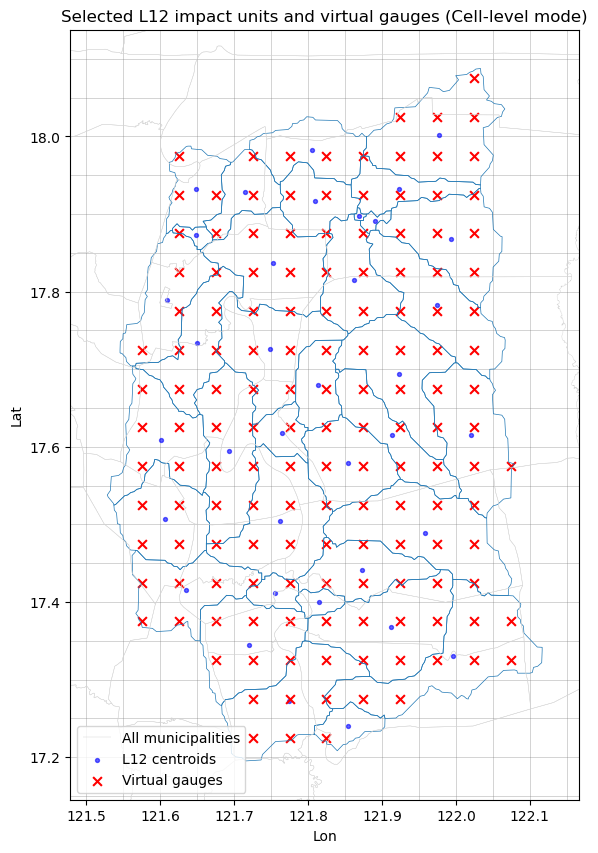

In [10]:
import geopandas as gpd
from shapely.geometry import Point

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Open one sample GRIB to get the GloFAS grid
inventory = discover_grib_year_files(glofas_grib_root)
sample_grib = inventory[0].grib_path
ds = open_grib_dataset(sample_grib, index_dir=index_dir)

# Add subtle GloFAS grid behind everything (bbox from selected_l12)
bbox = tuple(selected_l12.geometry.total_bounds)  # Use selected_l12 bounds instead of adm3
add_glofas_grid_overlay(ax, ds, bbox_lonlat=bbox, pad_deg=0.15)

try:
    ds.close()
except Exception:
    pass

# Base: selected L12
selected_l12.boundary.plot(ax=ax, linewidth=0.5)
# ALL municipalities (light background)
adm3_gdf.boundary.plot(ax=ax, linewidth=0.3, color="lightgray", alpha=1, label="All municipalities")

# AOI (if any) - only in municipality mode
if USE_MUNI_AOI:
    aoi_gdf = gpd.GeoDataFrame({"geometry": aoi_geoms}, crs="EPSG:4326")
    aoi_gdf.boundary.plot(ax=ax, linewidth=1.5, color="purple", label="AOI buffer")
    adm3_gdf[adm3_gdf[adm3_id_field].isin(adm3_ids)].boundary.plot(ax=ax, linewidth=2.0, color="red", label="Selected municipalities")

# Pour points or cell source points (depends on extraction mode)
if USE_CELL_EXTRACTION:
    # Cell-level: cells_within_polygon doesn't produce pour points, only cell coordinates
    # Show the L12 centroids instead for reference
    l12_centroids = selected_l12.copy()
    l12_centroids['geometry'] = l12_centroids.geometry.centroid
    l12_centroids.plot(ax=ax, markersize=8, color='blue', label='L12 centroids', alpha=0.6)
else:
    # Pour-point mode: show the pour points
    pp = gpd.GeoDataFrame(points_df, geometry=[Point(xy) for xy in zip(points_df.pour_lon, points_df.pour_lat)], crs="EPSG:4326")
    pp.plot(ax=ax, markersize=8, label='Pour points')

# Virtual gauges (unique cells)
vg_unique = points_df.drop_duplicates("virtual_gauge_id").copy()
vg = gpd.GeoDataFrame(vg_unique, geometry=[Point(xy) for xy in zip(vg_unique.lon, vg_unique.lat)], crs="EPSG:4326")
vg.plot(ax=ax, markersize=40, marker="x", color='red', label='Virtual gauges')

ax.set_title(f"Selected L12 impact units and virtual gauges ({'Cell-level' if USE_CELL_EXTRACTION else 'Pour-point'} mode)")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.legend()

# Zoom to selected_l12 bounds (centered, tight)
bounds = selected_l12.geometry.total_bounds
minx, miny, maxx, maxy = bounds
pad = 0.05  # degrees; small padding for tightness
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)

plt.show()


## 7) Write mapping tables 

We write:
- municipality → AOI → selected L12 (if AOI mode)
- L12 → pour point
- L12 → virtual gauge (GloFAS cell) + collision sizes


In [11]:
log.section("SECTION 7: Write Mapping Tables")

out_root = processed_root / "calibration" / "evt_pot" / (basin_cfg.basin_id if basin_cfg else "MUNI_SELECTION") / run_tag
mapping_dir = out_root / "mapping"
aoi_dir = out_root / "aoi"
for d in [mapping_dir, aoi_dir]:
    d.mkdir(parents=True, exist_ok=True)

log.step("Writing mapping tables...")

# A) muni → AOI → L12
if USE_MUNI_AOI:
    muni_aoi_df = pd.DataFrame(muni_aoi_records)
    muni_aoi_df.to_parquet(mapping_dir / "muni_aoi_l12.parquet", index=False)
    log.step(f"Wrote {len(muni_aoi_df)} municipality AOI records")

    # Save AOI geometries
    import geopandas as gpd
    aoi_gdf = gpd.GeoDataFrame(muni_aoi_df[["adm3_id", "centroid_lon", "centroid_lat", "total_population", "valid_pixel_count"]].copy(),
                              geometry=aoi_geoms, crs="EPSG:4326")
    aoi_gdf.to_file(aoi_dir / "municipality_aoi.geojson", driver="GeoJSON")
    log.step(f"Wrote AOI geometries to {aoi_dir}")

# B) L12 → grid cell mapping (adaptive to both extraction modes)
if USE_CELL_EXTRACTION:
    # Cell-level mode: L12 → cells (many cells per L12 possible)
    l12_cells = points_df[["l12_id", "lat", "lon"]].copy()
    l12_cells.to_parquet(mapping_dir / "l12_cell_coordinates.parquet", index=False)
    log.step(f"Wrote {len(l12_cells)} L12↔cell mappings")
else:
    # Pour-point mode: L12 → single pour point → single cell
    l12_pour = points_df[["l12_id", "pour_lon", "pour_lat"]].copy()
    l12_pour.to_parquet(mapping_dir / "l12_pour_points.parquet", index=False)
    log.step(f"Wrote {len(l12_pour)} pour point coordinates")

# C) L12 → virtual gauge (unique cell ID)
l12_vg = points_df[["l12_id", "virtual_gauge_id", "lat", "lon"]].drop_duplicates("virtual_gauge_id").copy()
l12_vg.to_parquet(mapping_dir / "l12_virtual_gauge.parquet", index=False)
log.step(f"Wrote {len(l12_vg)} L12↔virtual gauge mappings")

# D) Virtual gauge collision groups (how many L12s share each cell)
if USE_CELL_EXTRACTION:
    # For cell-level, we already have l12_count in points_df
    vg_collision = points_df[["virtual_gauge_id", "l12_count"]].drop_duplicates("virtual_gauge_id").copy()
else:
    # For pour-point mode, also already computed in Section 5
    vg_collision = points_df[["virtual_gauge_id", "collision_group_size"]].drop_duplicates("virtual_gauge_id").copy()
    vg_collision = vg_collision.rename(columns={"collision_group_size": "l12_count"})

vg_collision.to_parquet(mapping_dir / "virtual_gauge_collision_sizes.parquet", index=False)
log.step(f"Wrote collision group sizes for {len(vg_collision)} virtual gauges")

log.success("Section 7 complete: Mapping tables written")



  SECTION 7: Write Mapping Tables
• Writing mapping tables...
• Wrote 147 L12↔cell mappings
• Wrote 147 L12↔virtual gauge mappings
• Wrote collision group sizes for 147 virtual gauges
✓ Section 7 complete: Mapping tables written


In [12]:
log.section("SECTION 6B: Validate GRIB Files")

from pathlib import Path

bad = []
small = []
ok = 0

log.step("Checking GRIB file integrity...")

for item in inventory:
    p = Path(item.grib_path)
    if not p.exists():
        bad.append((item.year, "MISSING", str(p)))
        continue

    size = p.stat().st_size
    head = p.open("rb").read(4)

    if head != b"GRIB":
        bad.append((item.year, f"NOT_GRIB magic={head!r}", str(p)))
        continue

    if size < 5 * 1024 * 1024:  # <5MB is suspicious for "yearly consolidated discharge"
        small.append((item.year, f"{size/1024**2:.2f} MB", str(p)))
        continue

    ok += 1

log.table("GRIB Integrity Check", {
    "OK files": ok,
    "Missing files": len(bad),
    "Suspiciously small": len(small),
})

if bad:
    log.warn(f"BAD examples: {bad[:5]}")
if small:
    log.warn(f"SMALL examples: {small[:5]}")

log.success("GRIB file validation complete")


  SECTION 6B: Validate GRIB Files
• Checking GRIB file integrity...

GRIB Integrity Check:
  OK files................................ 47
  Missing files........................... 0
  Suspiciously small...................... 0
✓ GRIB file validation complete


## 8) GRIB → daily discharge time series 
We extract only the **unique virtual gauges** needed for this run.

- Auto-detect available years
- Skip already-processed gauge parquet files (unless forced)


In [13]:
# ============================================================================
# 8a) EXTRACTION METHOD CONFIGURATION
# ============================================================================
# Choose extraction method and configure memory optimization.
#
# ⭐ STREAMING EXTRACTION (RECOMMENDED) ⭐
# - Processes one year at a time, writes immediately to disk
# - Constant memory usage regardless of dataset size
# - Scales to country-level deployments (1000s of gauges)
# - Supports resumption if crashes occur
# - Works on cloud and local machines
#
# LEGACY EXTRACTION (Original method)
# - Loads all years into memory, then writes
# - Memory usage grows with years × gauges
# - Uses memory optimization tricks to reduce usage
# - May still crash on large datasets

# ⚠️ CHOOSE ONE:
USE_STREAMING = True  # ← RECOMMENDED: Year-by-year streaming (constant memory)
USE_MEMORY_OPTIMIZATION = True  # ← Only used if USE_STREAMING=False

# Gauge batch size (only for legacy mode when USE_STREAMING=False)
# Streaming mode always processes all gauges per year for efficiency
GAUGE_BATCH_SIZE = 2

# Memory thresholds (only for legacy mode)
MEMORY_WARNING_THRESHOLD = 70.0
MEMORY_ERROR_THRESHOLD = 85.0

print(f"\n{'='*80}")
if USE_STREAMING:
    print(f"⭐ STREAMING EXTRACTION ENABLED (RECOMMENDED)")
    print(f"{'='*80}")
    print(f"  • Architecture:           Year-by-year sequential processing")
    print(f"  • Memory usage:           Constant (only 1 year in RAM at a time)")
    print(f"  • Intermediate files:     Temp parquet per year → merged at end")
    print(f"  • Resumption:             YES (skips already-extracted years)")
    print(f"  • Scales to:              1000s of gauges, 50+ years")
    print(f"  • Recommended for:        All deployments (local & cloud)")
    print(f"{'='*80}\n")
elif USE_MEMORY_OPTIMIZATION:
    print(f"🔧 LEGACY MODE with Memory Optimization")
    print(f"{'='*80}")
    print(f"  • Geographic chunking:    YES (reduce grid size)")
    print(f"  • Gauge batching:         YES (batch size: {GAUGE_BATCH_SIZE})")
    print(f"  • Memory monitoring:      YES (warn: {MEMORY_WARNING_THRESHOLD}%, stop: {MEMORY_ERROR_THRESHOLD}%)")
    print(f"  • Note:                   May still crash on large datasets")
    print(f"{'='*80}\n")
else:
    print(f"⚠️  LEGACY MODE WITHOUT OPTIMIZATION (Not recommended)")
    print(f"{'='*80}\n")


⭐ STREAMING EXTRACTION ENABLED (RECOMMENDED)
  • Architecture:           Year-by-year sequential processing
  • Memory usage:           Constant (only 1 year in RAM at a time)
  • Intermediate files:     Temp parquet per year → merged at end
  • Resumption:             YES (skips already-extracted years)
  • Scales to:              1000s of gauges, 50+ years
  • Recommended for:        All deployments (local & cloud)



In [14]:
log.section("SECTION 8: Extracting Discharge Time Series")

timeseries_dir = processed_root / "glofas" / "v4" / "area_35_63_4_131" / "timeseries" / "virtual_gauges"
timeseries_dir.mkdir(parents=True, exist_ok=True)

# vg_points already created in Section 5, just verify it's set up correctly
if "lat" not in vg_points.columns or "lon" not in vg_points.columns:
    log.error("vg_points missing 'lat' or 'lon' columns!")
    raise KeyError("vg_points missing required columns")

log.table("Extraction Setup", {
    "Unique gauges": len(vg_points),
    "Total GRIB files": len(inventory),
    "Year range": f"{inventory[0].year}–{inventory[-1].year}",
    "Extraction method (spatial)": "Cell-level (all cells within polygon)" if USE_CELL_EXTRACTION else "Pour point (single outlet)",
    "Extraction method (temporal)": "STREAMING (year-by-year)" if USE_STREAMING else ("Memory-optimized" if USE_MEMORY_OPTIMIZATION else "Legacy"),
    "Gauge batch size": GAUGE_BATCH_SIZE if (not USE_STREAMING and USE_MEMORY_OPTIMIZATION) else "N/A",
})

if SELECTED_YEARS is not None:
    filtered_inventory = [i for i in inventory if i.year in SELECTED_YEARS]
    log.warn(f"Processing only {len(filtered_inventory)} selected years: {SELECTED_YEARS}")
else:
    filtered_inventory = inventory

log.step("Extracting discharge (this may take several minutes)...")

# === EXTRACTION WITH DETAILED LOGGING ===
import time
import psutil

start_time = time.time()


  SECTION 8: Extracting Discharge Time Series

Extraction Setup:
  Unique gauges........................... 147
  Total GRIB files........................ 47
  Year range.............................. 1979–2025
  Extraction method (spatial)............. Cell-level (all cells within polygon)
  Extraction method (temporal)............ STREAMING (year-by-year)
  Gauge batch size........................ N/A
• Extracting discharge (this may take several minutes)...


## 10) Interactive threshold selection (choose a gauge and find its POT threshold)

Use this block to pick a virtual gauge, review diagnostics, and lock in the POT threshold that will feed the save/log steps below. Nothing is written to disk in this section.

**Flow**
1. Run the widget to inspect diagnostics for a gauge (auto threshold is highlighted).
2. (Optional) Review candidate threshold stats to override manually.
3. Finalize the threshold to set `threshold_m3s`, `pot`, and `xi_sigma` for the save step.



In [15]:
import math
import numpy as np
import pandas as pd
from pyextremes import EVA

def _dynamic_min_events_total(
    coverage_years: float,
    target_lambda_rse: float = 0.20,   # 20% relative SE on lambda -> ~25 events
    min_floor: int = 10,
    max_events_per_year: float = 6.0,  # cap so short records don't force too-low thresholds
    want_gpd_params: bool = True,
):
    # For Poisson counts N ~ Pois(lambda*T), RSE(lambda_hat) ~ 1/sqrt(N)
    n_rate = math.ceil(1.0 / (target_lambda_rse ** 2))  # 0.20 -> 25
    n_gpd = 50 if want_gpd_params else 0               # classic heuristic for stable GPD params
    n_req = max(min_floor, n_rate, n_gpd)
    n_cap = max(min_floor, math.ceil(max_events_per_year * max(coverage_years, 0.0)))
    n_final = min(n_req, n_cap)
    status = "ok" if n_final == n_req else "capped_short_record"
    return int(n_final), status

def _get_fit_params(eva: EVA):
    """Robustly read fitted params from pyextremes model."""
    model = getattr(eva, "model", None)
    if model is None:
        return None
    # documented property
    fitp = getattr(model, "fit_parameters", None)
    if isinstance(fitp, dict) and len(fitp) > 0:
        return fitp
    # fallback (some versions expose params)
    fitp = getattr(model, "params", None)
    if isinstance(fitp, dict) and len(fitp) > 0:
        return fitp
    return None

def auto_select_threshold_pot(
    s: pd.Series,
    candidate_quantiles=(0.90, 0.92, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99),
    run_length_days: int = 5,
    min_events_total: int | str = "auto",          # int or "auto"
    target_lambda_range: tuple[float, float] | None = (1.0, 4.0),  # set None to disable
    stability_k: int = 3,                           # require stable region across k thresholds
    stability_tol_xi: float = 0.15,                 # abs range of xi within window
    stability_tol_sigma: float = 0.35,              # relative range of sigma within window
    dispersion_range: tuple[float, float] | None = (0.5, 2.0),
    dispersion_hard: bool = False,                  # False -> flag only; True -> gate
    require_gpd_params: bool = False,                # if True, thresholds without xi/sigma never pass
    verbose: bool = False,
):
    """
    Select the smallest threshold that yields declustered POT extremes consistent with GPD
    (operationalized via parameter-stability over a window) plus minimum event sufficiency.
    This follows the standard threshold-selection goal: pick the smallest threshold in a stable tail regime. :contentReference[oaicite:3]{index=3}
    """
    s = s.dropna().sort_index()
    if len(s) < 30 or not isinstance(s.index, pd.DatetimeIndex):
        raise ValueError("Input series must be a non-empty daily Series with a DatetimeIndex.")

    years = np.arange(s.index.min().year, s.index.max().year + 1)
    coverage_years = float(len(s) / 365.25)

    # Dynamic min events (optional)
    min_events_status = "fixed"
    if isinstance(min_events_total, str) and min_events_total.lower() == "auto":
        min_events_total, min_events_status = _dynamic_min_events_total(
            coverage_years=coverage_years,
            want_gpd_params=require_gpd_params,
        )

    thresholds = sorted({float(s.quantile(q)) for q in candidate_quantiles})
    r = f"{int(run_length_days)}D"

    eva = EVA(s)  # reuse for speed; get_extremes resets internal state
    rows = []

    for u in thresholds:
        eva.get_extremes(method="POT", threshold=float(u), r=r, extremes_type="high")
        ev = eva.extremes

        annual = ev.groupby(ev.index.year).size().reindex(years, fill_value=0)
        lam = float(annual.mean())
        disp = float((annual.var(ddof=1) / annual.mean())) if annual.mean() > 0 else np.nan

        xi = sigma = np.nan
        fit_ok = False
        try:
            eva.fit_model(distribution="genpareto")
            fit_params = _get_fit_params(eva)
            if isinstance(fit_params, dict):
                xi = float(fit_params.get("shape", fit_params.get("c", np.nan)))
                sigma = float(fit_params.get("scale", np.nan))
                fit_ok = (not np.isnan(xi)) and (not np.isnan(sigma)) and (sigma > 0)
        except Exception:
            fit_ok = False

        rows.append({
            "threshold": float(u),
            "n_events": int(len(ev)),
            "coverage_years": coverage_years,
            "lambda_per_year": lam,
            "dispersion_var_over_mean": disp,
            "xi": xi,
            "sigma": sigma,
            "gpd_fit_ok": bool(fit_ok),
        })

    df = pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)

    # --- build pass flags ---
    df["meets_events"] = df["n_events"] >= int(min_events_total)

    if target_lambda_range is None:
        df["meets_lambda"] = True
    else:
        lo, hi = target_lambda_range
        df["meets_lambda"] = (df["lambda_per_year"] >= lo) & (df["lambda_per_year"] <= hi)

    if dispersion_range is None:
        df["meets_dispersion"] = True
    else:
        dlo, dhi = dispersion_range
        df["meets_dispersion"] = df["dispersion_var_over_mean"].between(dlo, dhi, inclusive="both")

    # Parameter stability over a rolling window of size k
    df["stable_k"] = False
    for i in range(len(df)):
        j0 = i - (stability_k - 1)
        if j0 < 0:
            continue
        win = df.loc[j0:i, ["xi", "sigma", "gpd_fit_ok"]]
        if require_gpd_params and (not win["gpd_fit_ok"].all()):
            continue
        if win["xi"].isna().any() or win["sigma"].isna().any():
            continue
        xi_range = float(win["xi"].max() - win["xi"].min())
        sigma_min = float(win["sigma"].min())
        sigma_max = float(win["sigma"].max())
        sigma_rel = (sigma_max / sigma_min - 1.0) if sigma_min > 0 else np.inf

        if (xi_range <= stability_tol_xi) and (sigma_rel <= stability_tol_sigma):
            df.at[i, "stable_k"] = True

    # Final pass logic
    if dispersion_hard:
        df["passes"] = df["meets_events"] & df["meets_lambda"] & df["meets_dispersion"] & df["stable_k"]
    else:
        df["passes"] = df["meets_events"] & df["meets_lambda"] & df["stable_k"]
        # still keep dispersion as QC flag
        df["dispersion_flag"] = ~df["meets_dispersion"]

    # Pick the smallest threshold in a stable region
    if df["passes"].any():
        pick = float(df.loc[df["passes"]].iloc[0]["threshold"])
        status = "ok"
    else:
        # fallback: pick smallest threshold that at least meets events (or highest threshold if nothing meets)
        if df["meets_events"].any():
            pick = float(df.loc[df["meets_events"]].iloc[0]["threshold"])
            status = "fallback_events_only_no_stable_region"
        else:
            pick = float(df.iloc[-1]["threshold"])
            status = "fallback_no_threshold_passed"

    if verbose:
        print(f"[auto_select_threshold_pot] min_events_total={min_events_total} ({min_events_status}), "
              f"target_lambda_range={target_lambda_range}, stability_k={stability_k}, status={status}, pick={pick:.2f}")

    # store key config in attrs for traceability
    df.attrs = {
        "run_length_days": int(run_length_days),
        "min_events_total": int(min_events_total),
        "min_events_status": min_events_status,
        "target_lambda_range": target_lambda_range,
        "stability_k": int(stability_k),
        "stability_tol_xi": float(stability_tol_xi),
        "stability_tol_sigma": float(stability_tol_sigma),
        "dispersion_range": dispersion_range,
        "dispersion_hard": bool(dispersion_hard),
        "require_gpd_params": bool(require_gpd_params),
    }

    return pick, status, df


In [16]:
# ============================================================================
# 8a) DISCHARGE TIME SERIES EXTRACTION
# ============================================================================
# Extract discharge data for all virtual gauges from GRIB files
# Using streaming mode for memory efficiency

log.section("SECTION 8A: Time Series Extraction")

# Prepare extraction parameters
series_root = processed_root / "calibration" / "evt_pot" / (basin_cfg.basin_id if basin_cfg else "MUNI_SELECTION") / run_tag / "timeseries"
cfgrib_index_dir = processed_root / "glofas" / "v4" / "area_35_63_4_131" / "_cfgrib_index"

log.step("Extracting daily discharge from GRIB files...")
log.step(f"Output directory: {series_root}")

# Call extraction function with streaming enabled
series_by_gauge = load_or_build_gauge_timeseries(
    grib_inventory=filtered_inventory,
    points=vg_points,
    processed_timeseries_dir=series_root,
    cfgrib_index_dir=cfgrib_index_dir,
    force=False,  # use cached if available
    discharge_var=discharge_var,
    selected_years=SELECTED_YEARS,
    use_streaming=USE_STREAMING,
    use_memory_optimization=USE_MEMORY_OPTIMIZATION,
    gauge_batch_size=GAUGE_BATCH_SIZE,
)

log.success(f"Section 8A complete: Extracted {len(series_by_gauge)} gauge time series")


  SECTION 8A: Time Series Extraction
• Extracting daily discharge from GRIB files...
• Output directory: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\timeseries
✓ Section 8A complete: Extracted 147 gauge time series


In [17]:
import numpy as np
import pandas as pd
from pathlib import Path

from pyextremes import EVA

# Ensure helper is available even if previous cell was skipped
try:
    auto_select_threshold_pot
except NameError:
    from pyextremes import EVA as _EVA
    def auto_select_threshold_pot(
        s: pd.Series,
        candidate_quantiles=(0.90, 0.92, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99),
        run_length_days=5,
        min_events_total=50,
        stability_tol_xi=0.15,
        stability_tol_sigma=0.35,
        dispersion_range=(0.5, 2.0),
        verbose=False,
    ):
        if verbose:
            print(f"[auto_select_threshold_pot] Received parameters:")
            print(f"  candidate_quantiles: {candidate_quantiles}")
            print(f"  run_length_days: {run_length_days}")
            print(f"  min_events_total: {min_events_total}")
            print(f"  stability_tol_xi: {stability_tol_xi}")
            print(f"  stability_tol_sigma: {stability_tol_sigma}")
            print(f"  dispersion_range: {dispersion_range}")
        s = s.dropna().sort_index()
        years = np.arange(s.index.min().year, s.index.max().year + 1)
        thresholds = sorted({float(s.quantile(q)) for q in candidate_quantiles})
        rows = []
        prev_xi = prev_sigma = None
        for u in thresholds:
            eva = _EVA(s)
            eva.get_extremes(method="POT", threshold=float(u), r=f"{int(run_length_days)}D", extremes_type="high")
            ev = eva.extremes
            annual = ev.groupby(ev.index.year).size().reindex(years, fill_value=0)
            lam = annual.mean()
            disp = (annual.var(ddof=1) / annual.mean()) if annual.mean() > 0 else np.nan
            xi = sigma = np.nan
            try:
                eva.fit_model(distribution="genpareto")
                params = getattr(getattr(eva, "model", None), "params", None)
                if isinstance(params, dict):
                    xi = float(params.get("shape", params.get("c", np.nan)))
                    sigma = float(params.get("scale", np.nan))
            except Exception:
                pass
            stable = True
            if prev_xi is not None and not np.isnan(xi) and not np.isnan(prev_xi):
                stable &= (abs(xi - prev_xi) <= stability_tol_xi)
            if prev_sigma is not None and not np.isnan(sigma) and not np.isnan(prev_sigma) and prev_sigma > 0:
                stable &= (abs((sigma / prev_sigma) - 1.0) <= stability_tol_sigma)
            passes = ((len(ev) >= min_events_total) and (dispersion_range[0] <= disp <= dispersion_range[1]) and stable)
            rows.append({
                "threshold": u,
                "n_events": int(len(ev)),
                "lambda_per_year": float(lam),
                "dispersion_var_over_mean": float(disp) if disp == disp else np.nan,
                "xi": float(xi) if xi == xi else np.nan,
                "sigma": float(sigma) if sigma == sigma else np.nan,
                "stable_vs_prev": bool(stable),
                "passes": bool(passes),
            })
            prev_xi, prev_sigma = xi, sigma
        df = pd.DataFrame(rows).sort_values("threshold")
        if df["passes"].any():
            pick = float(df.loc[df["passes"]].iloc[0]["threshold"])
            status = "ok"
        else:
            pick = float(df.iloc[-1]["threshold"])
            status = "fallback_no_threshold_passed"
        return pick, status, df

# ============================================================================
# BATCH PROCESSING: Generate diagnostic stats + auto-select thresholds
# for ALL gauges. This runs once to populate the results folder.
# ============================================================================

# --- Calibration config (centralized for consistency across all Section 10 cells) ---
RUN_LENGTH_DAYS = int(run_length_days)  # uses notebook variable from Section 1
CANDIDATE_QUANTILES = candidate_quantiles if "candidate_quantiles" in globals() else (0.90, 0.92, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99)
MIN_EVENTS_TOTAL = "auto"  # minimum events required for a threshold to pass
STABILITY_TOL_XI = 0.15
STABILITY_TOL_SIGMA = 0.35
DISPERSION_RANGE = (0.5, 2.0)

MIN_EVENTS_TOTAL = "auto"              # <- dynamic per gauge
TARGET_LAMBDA_RANGE = (1.0, 4.0)       # <- optional; set None to disable
STABILITY_K = 3
DISPERSION_HARD = False               # <- keep dispersion as flag for now

# Output location
diag_root = (out_root / "results" / "diagnostics_by_gauge") if "out_root" in globals() else Path("./results/diagnostics_by_gauge")
diag_root.mkdir(parents=True, exist_ok=True)

print(f"=" * 70)
print(f"BATCH DIAGNOSTICS CONFIG:")
print(f"  RUN_LENGTH_DAYS:      {RUN_LENGTH_DAYS}")
print(f"  CANDIDATE_QUANTILES:  {CANDIDATE_QUANTILES}")
print(f"  MIN_EVENTS_TOTAL:     {MIN_EVENTS_TOTAL}")
print(f"  STABILITY_TOL_XI:     {STABILITY_TOL_XI}")
print(f"  STABILITY_TOL_SIGMA:  {STABILITY_TOL_SIGMA}")
print(f"  DISPERSION_RANGE:     {DISPERSION_RANGE}")
print(f"=" * 70)

summary_rows = []

gauge_ids = sorted(series_by_gauge.keys())
print(f"\nGenerating diagnostics for {len(gauge_ids)} gauge(s)…")
print(f"Output folder: {diag_root.resolve()}\n")

for i, gid in enumerate(gauge_ids, start=1):
    s = series_by_gauge[gid].dropna().sort_index()
    if len(s) == 0:
        continue

    coverage_years = float(len(s) / 365.25)
    q95 = float(s.quantile(0.95))

    pick_u, pick_status, diag_df = auto_select_threshold_pot(
        s,
        candidate_quantiles=CANDIDATE_QUANTILES,
        run_length_days=RUN_LENGTH_DAYS,
        min_events_total=MIN_EVENTS_TOTAL,
        target_lambda_range=TARGET_LAMBDA_RANGE,
        stability_k=STABILITY_K,
        stability_tol_xi=STABILITY_TOL_XI,
        stability_tol_sigma=STABILITY_TOL_SIGMA,
        dispersion_range=DISPERSION_RANGE,
        dispersion_hard=DISPERSION_HARD,
        require_gpd_params=True,
        verbose=False,
)

    gdir = diag_root / gid
    gdir.mkdir(parents=True, exist_ok=True)

    # Save diagnostics table per gauge
    diag_df.to_parquet(gdir / "threshold_diagnostics.parquet", index=False)

    summary_rows.append({
        "virtual_gauge_id": gid,
        "coverage_years": coverage_years,
        "q95_m3s": q95,
        "u_auto_m3s": float(pick_u),
        "auto_status": pick_status,
        "n_events_at_u_auto": int(diag_df.loc[diag_df["threshold"] == pick_u, "n_events"].iloc[0]) if (diag_df["threshold"] == pick_u).any() else np.nan,
        "auto_status": pick_status,
        "dispersion_flag_at_pick": bool(diag_df.loc[diag_df["threshold"] == pick_u, "dispersion_flag"].iloc[0]) if "dispersion_flag" in diag_df.columns else False,
    })

    if i % 10 == 0 or i == len(gauge_ids):
        print(f"  [{i}/{len(gauge_ids)}] done")

# Save aggregate summary
summary_df = pd.DataFrame(summary_rows).sort_values(["auto_status", "coverage_years"], ascending=[True, False])
summary_df.to_parquet(diag_root / "_summary.parquet", index=False)
print(f"\n✓ Batch diagnostics complete. Summary saved to: {diag_root / '_summary.parquet'}")
display(summary_df.head(20))


BATCH DIAGNOSTICS CONFIG:
  RUN_LENGTH_DAYS:      5
  CANDIDATE_QUANTILES:  [0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
  MIN_EVENTS_TOTAL:     auto
  STABILITY_TOL_XI:     0.15
  STABILITY_TOL_SIGMA:  0.35
  DISPERSION_RANGE:     (0.5, 2.0)

Generating diagnostics for 147 gauge(s)…
Output folder: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\results\diagnostics_by_gauge

  [10/147] done
  [20/147] done
  [30/147] done
  [40/147] done
  [50/147] done
  [60/147] done
  [70/147] done
  [80/147] done
  [90/147] done
  [100/147] done
  [110/147] done
  [120/147] done
  [130/147] done
  [140/147] done
  [147/147] done

✓ Batch diagnostics complete. Summary saved to: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\results\diagnostics_by_gauge\_summary.parquet


,virtual_gauge_id,coverage_years,q95_m3s,u_auto_m3s,auto_status,n_events_at_u_auto,dispersion_flag_at_pick
0,CELL__lat_17.2250__lon_121.7250,46.833676,4.296875,5.390625,ok,175,False
1,CELL__lat_17.2250__lon_121.7750,46.833676,185.085938,203.037500,ok,188,False
2,CELL__lat_17.2250__lon_121.8250,46.833676,2672.259766,2672.259766,ok,185,False
3,CELL__lat_17.2750__lon_121.7250,46.833676,4.591797,5.750000,ok,182,False
4,CELL__lat_17.2750__lon_121.7750,46.833676,13.718750,17.276562,ok,180,False
5,CELL__lat_17.2750__lon_121.8250,46.833676,2721.667969,2721.667969,ok,184,False
6,CELL__lat_17.2750__lon_121.8750,46.833676,49.585938,65.078125,ok,160,False
7,CELL__lat_17.2750__lon_121.9250,46.833676,45.273438,59.026172,ok,161,False
8,CELL__lat_17.3250__lon_121.6750,46.833676,4.531250,5.718750,ok,174,False
9,CELL__lat_17.3250__lon_121.7250,46.833676,22.646484,28.617969,ok,174,False


In [18]:
# ============================================================================
# STEP 1: Select a gauge and view diagnostics + auto-recommended threshold
# ============================================================================
import logging
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from pyextremes import EVA, plot_mean_residual_life, plot_parameter_stability
from pyextremes.plotting.extremes import plot_extremes

logging.getLogger("pyextremes").setLevel(logging.WARNING)

print(f"Using config from batch processing cell:")
print(f"  RUN_LENGTH_DAYS:      {RUN_LENGTH_DAYS}")
print(f"  CANDIDATE_QUANTILES:  {CANDIDATE_QUANTILES}")
print(f"  MIN_EVENTS_TOTAL:     {MIN_EVENTS_TOTAL}")
print(f"  STABILITY_TOL_XI:     {STABILITY_TOL_XI}")
print(f"  STABILITY_TOL_SIGMA:  {STABILITY_TOL_SIGMA}")
print(f"  DISPERSION_RANGE:     {DISPERSION_RANGE}\n")


def _plot_mrl(s, q95, pick_u):
    plot_mean_residual_life(s)
    ax = plt.gca()
    ax.axvline(q95, linestyle="--", linewidth=2, color="red", label=f"q95={q95:.2f}")
    ax.axvline(pick_u, linestyle="-.", linewidth=2, color="green", label=f"u*={pick_u:.2f}")
    ax.set_title("Mean Residual Life")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


def _plot_parameter_stability(s, q95, pick_u):
    thr_grid = np.linspace(float(s.quantile(0.90)), float(s.quantile(0.995)), 40)
    plot_parameter_stability(s, thresholds=thr_grid, r=f"{RUN_LENGTH_DAYS}D")
    ax = plt.gca()
    ax.axvline(q95, linestyle="--", linewidth=2, color="red", label=f"q95={q95:.2f}")
    ax.axvline(pick_u, linestyle="-.", linewidth=2, color="green", label=f"u*={pick_u:.2f}")
    ax.set_title(f"Parameter stability (r={RUN_LENGTH_DAYS}D)")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


def _plot_pot_extremes(s, pick_u):
    eva = EVA(s)
    eva.get_extremes(method="POT", threshold=float(pick_u), r=f"{RUN_LENGTH_DAYS}D", extremes_type="high")
    fig, ax = plt.subplots(figsize=(12, 5))
    plot_extremes(
        ts=s,
        extremes=eva.extremes,
        extremes_method="POT",
        extremes_type="high",
        threshold=float(pick_u),
        r=f"{RUN_LENGTH_DAYS}D",
        ax=ax,
    )
    ax.set_title(f"POT extremes (u*={pick_u:.2f}, r={RUN_LENGTH_DAYS}D)")
    plt.tight_layout()
    plt.show()


def show_gauge_diag(gid):
    """Display diagnostics for a selected gauge and store selection globally."""
    global selected_gauge_id, diag_df
    selected_gauge_id = gid
    s = series_by_gauge[gid].dropna().sort_index()
    q95 = float(s.quantile(0.95))

    pick_u, pick_status, diag_df = auto_select_threshold_pot(
        s,
        candidate_quantiles=CANDIDATE_QUANTILES,
        run_length_days=RUN_LENGTH_DAYS,
        min_events_total=MIN_EVENTS_TOTAL,
        stability_tol_xi=STABILITY_TOL_XI,
        stability_tol_sigma=STABILITY_TOL_SIGMA,
        dispersion_range=DISPERSION_RANGE,
        verbose=True,  # Show diagnostic info
    )

    _plot_mrl(s, q95, pick_u)
    _plot_parameter_stability(s, q95, pick_u)
    _plot_pot_extremes(s, pick_u)

    print(f"\nAUTO threshold selection: {pick_status}")
    print(f"Picked threshold: {pick_u:.2f} m³/s")
    display(diag_df)


if HAS_WIDGETS:
    dropdown = widgets.Dropdown(options=sorted(series_by_gauge.keys()), description="Gauge:")
    ui = widgets.interactive(show_gauge_diag, gid=dropdown)
    display(ui)
else:
    fallback_gid = sorted(series_by_gauge.keys())[0]
    print(f"Widgets not available. Using first gauge: {fallback_gid}")
    show_gauge_diag(fallback_gid)


Using config from batch processing cell:
  RUN_LENGTH_DAYS:      5
  CANDIDATE_QUANTILES:  [0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
  MIN_EVENTS_TOTAL:     auto
  STABILITY_TOL_XI:     0.15
  STABILITY_TOL_SIGMA:  0.35
  DISPERSION_RANGE:     (0.5, 2.0)



interactive(children=(Dropdown(description='Gauge:', options=('CELL__lat_17.2250__lon_121.7250', 'CELL__lat_17…

In [19]:
# STEP 2 (Optional): Review all candidate thresholds for manual override
# This table shows statistics for different threshold choices
# Usually, you'll accept the auto-selected threshold from the widget above

import pandas as pd
import numpy as np
from pyextremes import EVA

s = series_by_gauge[selected_gauge_id].dropna().sort_index()

print(f"Computing threshold statistics for: {selected_gauge_id}")
print(f"Using RUN_LENGTH_DAYS={RUN_LENGTH_DAYS}, CANDIDATE_QUANTILES={CANDIDATE_QUANTILES}\n")


def pot_stats(s, u, run_length_days):
    """Calculate POT statistics for a given threshold."""
    eva = EVA(s)
    eva.get_extremes(method="POT", threshold=float(u), r=f"{int(run_length_days)}D", extremes_type="high")
    ev = eva.extremes
    years = np.arange(s.index.min().year, s.index.max().year + 1)
    annual = ev.groupby(ev.index.year).size().reindex(years, fill_value=0)
    lam = annual.mean()
    disp = (annual.var(ddof=1) / annual.mean()) if annual.mean() > 0 else np.nan
    return dict(
        threshold=float(u),
        n_events=int(len(ev)),
        lambda_per_year=float(lam),
        dispersion=float(disp) if disp == disp else np.nan,
    )


cand = sorted({float(s.quantile(q)) for q in CANDIDATE_QUANTILES})
rows = [pot_stats(s, u, RUN_LENGTH_DAYS) for u in cand]
threshold_table = pd.DataFrame(rows).sort_values("threshold")
print("Candidate thresholds and their event counts:")
display(threshold_table)


Computing threshold statistics for: CELL__lat_17.2250__lon_121.7250
Using RUN_LENGTH_DAYS=5, CANDIDATE_QUANTILES=[0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]

Candidate thresholds and their event counts:


,threshold,n_events,lambda_per_year,dispersion
0,2.824219,330,7.021277,0.888538
1,3.015625,317,6.744681,0.853930
2,3.250000,307,6.531915,0.791106
3,3.515625,277,5.893617,0.901742
4,3.843750,256,5.446809,1.108016
5,4.296875,236,5.021277,1.112564
6,4.809375,208,4.425532,1.196070
7,5.390625,175,3.723404,1.140870
8,6.513281,129,2.744681,0.973711
9,8.616797,74,1.574468,0.793772


In [20]:
# STEP 3: Finalize threshold (use auto-selected or override manually)
# Set `threshold_override` to a float to bypass the auto-picked value.

threshold_override = None  # e.g., 250.0 to manually override

print(f"Finalizing threshold for: {selected_gauge_id}")
print(f"Config: RUN_LENGTH_DAYS={RUN_LENGTH_DAYS}, MIN_EVENTS_TOTAL={MIN_EVENTS_TOTAL}")
if threshold_override is not None:
    print(f"⚠️  MANUAL OVERRIDE: Using threshold_m3s={threshold_override}")

pick_u, pick_status, diag_df = auto_select_threshold_pot(
    s,
    candidate_quantiles=CANDIDATE_QUANTILES,
    run_length_days=RUN_LENGTH_DAYS,
    min_events_total=MIN_EVENTS_TOTAL,
    stability_tol_xi=STABILITY_TOL_XI,
    stability_tol_sigma=STABILITY_TOL_SIGMA,
    dispersion_range=DISPERSION_RANGE,
    verbose=False,
)

threshold_m3s = float(threshold_override) if threshold_override is not None else pick_u
pot = pot_extract(s, threshold_m3s=threshold_m3s, run_length_days=RUN_LENGTH_DAYS)
xi_sigma = fit_gpd_to_pot(s, threshold_m3s=threshold_m3s, run_length_days=RUN_LENGTH_DAYS)

print(f"\n{'='*60}")
print(f"FINAL RESULTS FOR: {selected_gauge_id}")
print(f"{'='*60}")
print(f"Selected threshold: {threshold_m3s:.2f} m³/s ({pick_status})")
if threshold_override is not None:
    print(f"  (MANUAL override, auto picked: {pick_u:.2f})")
print(f"Flood events found: {len(pot.events)}")
print(f"Lambda (avg events/year): {pot.lambda_events_per_year:.3f}")
print(f"Data coverage: {pot.coverage_years:.1f} years")
if xi_sigma:
    print(f"GPD shape (xi): {xi_sigma[0]:.4f}")
    print(f"GPD scale (sigma): {xi_sigma[1]:.4f}")
print(f"{'='*60}")


Finalizing threshold for: CELL__lat_17.2250__lon_121.7250
Config: RUN_LENGTH_DAYS=5, MIN_EVENTS_TOTAL=auto

FINAL RESULTS FOR: CELL__lat_17.2250__lon_121.7250
Selected threshold: 5.39 m³/s (ok)
Flood events found: 175
Lambda (avg events/year): 3.737
Data coverage: 46.8 years
GPD shape (xi): -0.0182
GPD scale (sigma): 3.7247


### How the automatic threshold selection works (non-technical explanation)

**The goal:** Find the best river discharge level to identify "flood" events

**The method:**
1. Tests different possible thresholds (from 90th to 99.9th percentile of flow)
2. For each threshold, calculates how many flood events it finds
3. Checks if the statistical model is **stable** (parameters don't jump around wildly)
4. Picks the **lowest threshold** that still has a stable model

**Why this matters:**
- Too LOW a threshold = every small rise is called a "flood" (too many false alarms)
- Too HIGH a threshold = miss real flood events (not enough data to fit model)
- We want the sweet spot: reliable statistics with meaningful flood events

**Technical detail:** Uses GPD (Generalized Pareto Distribution) and checks for stability in shape (ξ) and scale (σ) parameters across adjacent thresholds.

## 11) Save & Validate POT Calibration Outputs

**What this section does:** Extracts "extreme flood events" (called POT events) from the river discharge data.

**In plain language:**
- Uses the best threshold from Section 10 to find significant river events
- Saves each event with its date and discharge level
- Fits a mathematical model to describe how rare extreme events are
- Creates 4 output files: one for each monitoring station

**Outputs you'll see:**
- Event files with flood peaks
- A table with threshold values and statistical parameters
- Quality checks to make sure everything looks reasonable


In [21]:
events_dir = out_root / "events"
results_dir = out_root / "results"
logs_dir = out_root / "logs"
for d in [events_dir, results_dir, logs_dir]:
    d.mkdir(parents=True, exist_ok=True)

# Optional manual overrides per gauge (populate manually as needed)
# Example: MANUAL_THRESHOLD_OVERRIDES = {"VG__lat_12.3456__lon_98.7654": 250.0}
MANUAL_THRESHOLD_OVERRIDES = {}

print("Saving POT events and results for ALL gauges…")
print(f"Config: RUN_LENGTH_DAYS={RUN_LENGTH_DAYS}, MIN_EVENTS_TOTAL={MIN_EVENTS_TOTAL}, CANDIDATE_QUANTILES={CANDIDATE_QUANTILES}\n")

result_rows = []

for idx, (gid, s_raw) in enumerate(series_by_gauge.items(), start=1):
    s = s_raw.dropna().sort_index()
    if len(s) == 0:
        print(f"[{idx}/{len(series_by_gauge)}] {gid}: skipped (no data)")
        continue

    pick_u, pick_status, diag_df = auto_select_threshold_pot(
        s,
        candidate_quantiles=CANDIDATE_QUANTILES,
        run_length_days=RUN_LENGTH_DAYS,
        min_events_total=MIN_EVENTS_TOTAL,
        stability_tol_xi=STABILITY_TOL_XI,
        stability_tol_sigma=STABILITY_TOL_SIGMA,
        dispersion_range=DISPERSION_RANGE,
        verbose=False,
    )

    threshold_use = MANUAL_THRESHOLD_OVERRIDES.get(gid, pick_u)
    threshold_source = "manual_override" if gid in MANUAL_THRESHOLD_OVERRIDES else pick_status

    extraction_metadata = {
        'extraction_method': 'cell-level' if USE_CELL_EXTRACTION else 'pour-point',
        'context_mode': 'municipality-aoi' if USE_MUNI_AOI else 'context-basin',
    }
    pot_res = pot_extract(s, threshold_m3s=threshold_use, run_length_days=RUN_LENGTH_DAYS,
                          extraction_method=extraction_metadata['extraction_method'],
                          extraction_metadata=extraction_metadata)
    xi_sigma_local = fit_gpd_to_pot(s, threshold_m3s=threshold_use, run_length_days=RUN_LENGTH_DAYS)

    # Save events for this gauge
    pot_events_path = events_dir / f"{gid}__pot_events.parquet"
    pot_res.events.to_parquet(pot_events_path, index=False)

    result_rows.append({
        "virtual_gauge_id": gid,
        "threshold_m3s": pot_res.threshold_m3s,
        "threshold_source": threshold_source,
        "run_length_days": pot_res.run_length_days,
        "lambda_events_per_year": pot_res.lambda_events_per_year,
        "coverage_years": pot_res.coverage_years,
        "gpd_xi": float(xi_sigma_local[0]) if xi_sigma_local else None,
        "gpd_sigma": float(xi_sigma_local[1]) if xi_sigma_local else None,
    })

    if idx % 10 == 0 or idx == len(series_by_gauge):
        print(f"  [{idx}/{len(series_by_gauge)}] saved events + result row")

# Append/update aggregated results table
results_path = results_dir / "evt_pot_calibration.parquet"
if results_path.exists():
    existing = pd.read_parquet(results_path)
    # Drop rows for gauges we are overwriting in this run
    keep = existing[~existing["virtual_gauge_id"].isin([r["virtual_gauge_id"] for r in result_rows])]
    result_df = pd.concat([keep, pd.DataFrame(result_rows)], ignore_index=True)
else:
    result_df = pd.DataFrame(result_rows)

result_df.to_parquet(results_path, index=False)
print("\n✓ Wrote aggregated results:", results_path)
print("✓ Events directory:", events_dir)


Saving POT events and results for ALL gauges…
Config: RUN_LENGTH_DAYS=5, MIN_EVENTS_TOTAL=auto, CANDIDATE_QUANTILES=[0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]

  [10/147] saved events + result row
  [20/147] saved events + result row
  [30/147] saved events + result row
  [40/147] saved events + result row
  [50/147] saved events + result row
  [60/147] saved events + result row
  [70/147] saved events + result row
  [80/147] saved events + result row
  [90/147] saved events + result row
  [100/147] saved events + result row
  [110/147] saved events + result row
  [120/147] saved events + result row
  [130/147] saved events + result row
  [140/147] saved events + result row
  [147/147] saved events + result row

✓ Wrote aggregated results: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\results\evt_pot_calibration.parquet
✓ Events directory: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\

## 11b) QA — Verify POT calibration outputs

Quick validation of saved calibration results:
- Aggregated threshold & GPD parameter table
- Per-gauge event files with extracted POT events
- Summary statistics for all gauges


In [22]:
"""
Section 11b QA: Verify all POT calibration outputs were saved correctly.
Displays:
  - Aggregated results (one row per gauge)
  - List of event files
  - Sample event records from first gauge
"""

from pathlib import Path
import pandas as pd

print("=" * 90)
print("SECTION 11B: QUALITY ASSURANCE — POT Calibration Outputs")
print("=" * 90)

# Load aggregated results
results_path = results_dir / "evt_pot_calibration.parquet"
print(f"\n1) Aggregated Results Table")
print(f"   Path: {results_path}")

if results_path.exists():
    calib_results = pd.read_parquet(results_path)
    print(f"   ✓ Loaded {len(calib_results)} gauge calibrations")
    print(f"   Columns: {list(calib_results.columns)}")
    print(f"\n   Summary Statistics:")
    print(f"   - Threshold range: {calib_results['threshold_m3s'].min():.1f}–{calib_results['threshold_m3s'].max():.1f} m³/s")
    print(f"   - λ (events/year) range: {calib_results['lambda_events_per_year'].min():.2f}–{calib_results['lambda_events_per_year'].max():.2f}")
    print(f"   - Run length: {calib_results['run_length_days'].unique()}")
    print(f"\n   Threshold sources:")
    print(calib_results['threshold_source'].value_counts().to_string())
    print(f"\n   Table preview:")
    display(calib_results)
else:
    print(f"   ✗ Results file not found!")

# List event files
print(f"\n2) Per-Gauge Event Files")
if events_dir.exists():
    event_files = sorted(events_dir.glob("*__pot_events.parquet"))
    print(f"   ✓ Found {len(event_files)} POT event files")
    for i, p in enumerate(event_files, start=1):
        ev_sample = pd.read_parquet(p)
        print(f"   [{i}] {p.name}: {len(ev_sample)} events")
    
    # Sample from first gauge
    if event_files:
        print(f"\n3) Sample: First gauge POT events")
        event_path = event_files[0]
        df_events = pd.read_parquet(event_path)
        gauge_id = event_path.stem.replace("__pot_events", "")
        print(f"   Gauge: {gauge_id}")
        print(f"   Total events: {len(df_events)}")
        print(f"   Date range: {df_events['date'].min().date()} to {df_events['date'].max().date()}")
        print(f"   Discharge range: {df_events['discharge_m3s'].min():.1f}–{df_events['discharge_m3s'].max():.1f} m³/s")
        print(f"\n   Sample rows:")
        display(df_events.head(10))
else:
    print(f"   ✗ Events directory not found!")

print("\n" + "=" * 90)
print("✓ Section 11 QA complete")
print("=" * 90)


SECTION 11B: QUALITY ASSURANCE — POT Calibration Outputs

1) Aggregated Results Table
   Path: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\results\evt_pot_calibration.parquet
   ✓ Loaded 171 gauge calibrations
   Columns: ['virtual_gauge_id', 'threshold_m3s', 'threshold_source', 'run_length_days', 'lambda_events_per_year', 'coverage_years', 'gpd_xi', 'gpd_sigma']

   Summary Statistics:
   - Threshold range: 4.8–4643.2 m³/s
   - λ (events/year) range: 2.52–4.01
   - Run length: [5]

   Threshold sources:
threshold_source
ok    171

   Table preview:


,virtual_gauge_id,threshold_m3s,threshold_source,run_length_days,lambda_events_per_year,coverage_years,gpd_xi,gpd_sigma
0,VG__lat_17.9750__lon_121.6250,4643.243750,ok,5,3.629867,46.833676,-0.041307,3047.041233
1,VG__lat_17.8750__lon_121.6750,3378.992188,ok,5,4.014206,46.833676,-0.051658,2571.990840
2,VG__lat_17.8750__lon_121.6250,4.825000,ok,5,3.971501,46.833676,0.101695,4.729422
3,VG__lat_17.9250__lon_121.7750,265.281250,ok,5,3.501754,46.833676,0.146125,175.343598
4,VG__lat_17.7750__lon_121.7250,3162.636719,ok,5,4.014206,46.833676,-0.022407,2333.395241
...,...,...,...,...,...,...,...,...
166,CELL__lat_17.3250__lon_122.0250,44.857031,ok,5,3.480402,46.833676,-0.004451,29.456419
167,CELL__lat_17.3250__lon_122.0750,9.177344,ok,5,3.587162,46.833676,-0.012887,6.051081
168,CELL__lat_17.2750__lon_121.8250,2721.667969,ok,5,3.928797,46.833676,-0.043584,2230.424942
169,CELL__lat_17.2750__lon_121.8750,65.078125,ok,5,3.416345,46.833676,-0.018426,44.357729



2) Per-Gauge Event Files
   ✓ Found 171 POT event files
   [1] CELL__lat_17.2250__lon_121.7250__pot_events.parquet: 175 events
   [2] CELL__lat_17.2250__lon_121.7750__pot_events.parquet: 188 events
   [3] CELL__lat_17.2250__lon_121.8250__pot_events.parquet: 185 events
   [4] CELL__lat_17.2750__lon_121.7250__pot_events.parquet: 182 events
   [5] CELL__lat_17.2750__lon_121.7750__pot_events.parquet: 180 events
   [6] CELL__lat_17.2750__lon_121.8250__pot_events.parquet: 184 events
   [7] CELL__lat_17.2750__lon_121.8750__pot_events.parquet: 160 events
   [8] CELL__lat_17.2750__lon_121.9250__pot_events.parquet: 161 events
   [9] CELL__lat_17.3250__lon_121.6750__pot_events.parquet: 174 events
   [10] CELL__lat_17.3250__lon_121.7250__pot_events.parquet: 174 events
   [11] CELL__lat_17.3250__lon_121.7750__pot_events.parquet: 183 events
   [12] CELL__lat_17.3250__lon_121.8250__pot_events.parquet: 175 events
   [13] CELL__lat_17.3250__lon_121.8750__pot_events.parquet: 163 events
   [14] CELL__la

,date,discharge_m3s
0,1970-01-01 00:00:00.000000000,9.304688
1,1970-01-01 00:00:00.000000001,9.265625
2,1970-01-01 00:00:00.000000002,5.976562
3,1970-01-01 00:00:00.000000003,9.984375
4,1970-01-01 00:00:00.000000004,15.078125
5,1970-01-01 00:00:00.000000005,8.328125
6,1970-01-01 00:00:00.000000006,8.929688
7,1970-01-01 00:00:00.000000007,8.640625
8,1970-01-01 00:00:00.000000008,6.812500
9,1970-01-01 00:00:00.000000009,7.921875



✓ Section 11 QA complete


## 12) Synthetic Event Catalog Generation

Generate synthetic flood events for return-period analysis using the calibrated POT parameters:
- **Input:** Per-gauge thresholds, λ (Poisson rate), GPD shape (ξ) and scale (σ)
- **Method:** Poisson draws for annual event counts + GPD sampling for peak magnitudes
- **Output:** Synthetic event catalogs with dates, magnitudes, and theoretical return periods
- **Visualization:** Presentation-ready figures for stakeholder communication


In [23]:
# --- SECTION 12A: Configuration for synthetic event generation ---
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import warnings
from datetime import datetime, timezone

# USER-EDITABLE SETTINGS (Return-period driven)
MAX_RETURN_PERIOD_YEARS = 500         # Max return period to simulate
YEARS_PER_RETURN_PERIOD = 200       # Monte Carlo years per max RP (low=noisy but fast, high=stable but slow)
SIM_YEARS = int(MAX_RETURN_PERIOD_YEARS * YEARS_PER_RETURN_PERIOD)  # Total simulation years (10000)

# Return periods for diagnostics + stakeholder reports
RETURN_PERIODS_REPORT = [1,2,5,10,20,50,100,200,500]

# Synthetic calendar: ensure BASE_YEAR + SIM_YEARS < 2263 (pandas datetime64 limit)
BASE_YEAR = 1                     # Anchor year for synthetic dates
MIN_SEP_DAYS_WITHIN_YEAR = int(run_length_days) if "run_length_days" in globals() else 5  # Minimum separation (days)

# --- Synthetic calendar (INTEGER time; no pandas datetime64) ---
YEAR_INDEX_START = 1              # synthetic years start at 1
DAYS_PER_YEAR = 365               # keep fixed for simplicity (or 366 if you prefer)
MIN_SEP_DAYS_WITHIN_YEAR = int(run_length_days) if "run_length_days" in globals() else 5

# Convenience: a continuous time coordinate (years since start) for later models/plots
# t_years = (synthetic_year - YEAR_INDEX_START) + (synthetic_dayofyear - 1)/DAYS_PER_YEAR
STORE_CONTINUOUS_TIME = True

# Reproducibility & output controls
GLOBAL_SEED = 42
WRITE_COMBINED_ALL_GAUGES = False      # Write combined catalog (may be large)
SAVE_OPTIONAL_CSV = False             # Also save CSV (slow for large catalogs)

# Warnings thresholds
WARN_IF_SIM_YEARS_LT_MULTIPLE_OF_MAX_RP = 50
WARN_IF_EXPECTED_EVENTS_LT = 2000
WARN_IF_REAL_POT_EVENTS_LT = 50

# Output folders
run_dir = results_dir.parent
synthetic_root = run_dir / "synthetic_catalog"
events_out_dir = synthetic_root / "events"
rl_out_dir = synthetic_root / "return_levels"
meta_out_dir = synthetic_root / "metadata"
fig_dir = synthetic_root / "figures"

for d in [events_out_dir, rl_out_dir, meta_out_dir, fig_dir]:
    d.mkdir(parents=True, exist_ok=True)

print("=" * 90)
print("SECTION 12A: Synthetic Event Catalog Configuration")
print("=" * 90)
print(f"MAX_RETURN_PERIOD_YEARS:   {MAX_RETURN_PERIOD_YEARS}")
print(f"YEARS_PER_RETURN_PERIOD:   {YEARS_PER_RETURN_PERIOD}")
print(f"SIM_YEARS:                 {SIM_YEARS}")
print(f"BASE_YEAR:                 {BASE_YEAR} (range: {BASE_YEAR}–{BASE_YEAR + SIM_YEARS})")
print(f"INTEGER synthetic time: years {YEAR_INDEX_START}..{YEAR_INDEX_START + SIM_YEARS - 1}")
print(f"DAYS_PER_YEAR: {DAYS_PER_YEAR}")
print(f"Synthetic catalog root:    {synthetic_root}")
print("=" * 90)

if YEARS_PER_RETURN_PERIOD < WARN_IF_SIM_YEARS_LT_MULTIPLE_OF_MAX_RP:
    warnings.warn(f"YEARS_PER_RETURN_PERIOD={YEARS_PER_RETURN_PERIOD} is low; tail estimates will be noisy")


SECTION 12A: Synthetic Event Catalog Configuration
MAX_RETURN_PERIOD_YEARS:   500
YEARS_PER_RETURN_PERIOD:   200
SIM_YEARS:                 100000
BASE_YEAR:                 1 (range: 1–100001)
INTEGER synthetic time: years 1..100000
DAYS_PER_YEAR: 365
Synthetic catalog root:    C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\synthetic_catalog


In [24]:
# Section 12B — synthetic event generation (DECLUSTERED, timestamp-safe)
# Keeps existing file names + parquet formats. Stores integer time (sim_year/day) instead of pandas Timestamp.

import numpy as np
import pandas as pd
import warnings

# ---- Reproducibility ----
baseline_seed = int(GLOBAL_SEED)
rng_global = np.random.default_rng(baseline_seed)

EPS_XI = 1e-6

def stable_int_seed(s: str) -> int:
    """Stable per-gauge seed (independent of python hash randomization)."""
    # simple deterministic hash (FNV-1a-ish)
    h = 2166136261
    for ch in s.encode("utf-8"):
        h = (h ^ ch) * 16777619
        h &= 0xFFFFFFFF
    return int(h)

def sample_days_with_min_sep_in_year(rng, n, low=0, high=364, min_sep=5):
    """
    Sample n integer days in [low, high] such that all picked days are at least min_sep apart.
    Best-effort: caps n to the max feasible given the interval length.
    """
    if n <= 0:
        return np.array([], dtype=int)
    if low > high:
        return np.array([], dtype=int)

    span = high - low + 1
    max_possible = int(np.floor((span + (min_sep - 1)) / max(1, min_sep)))
    if n > max_possible:
        n = max_possible

    picked = []
    attempts = 0
    # rejection sampling; OK because n is usually small (lambda ~ few events/year)
    while len(picked) < n and attempts < 200000:
        d = int(rng.integers(low, high + 1))
        if all(abs(d - p) >= min_sep for p in picked):
            picked.append(d)
        attempts += 1

    return np.array(sorted(picked), dtype=int)

def sample_gpd_exceedances(rng: np.random.Generator, xi: float, sigma: float, size: int) -> np.ndarray:
    """Draw exceedances from GPD (xi, sigma). Handles xi≈0."""
    u = rng.random(size=size)
    xi = float(xi)
    sigma = float(sigma)

    if not np.isfinite(sigma) or sigma <= 0:
        raise ValueError("Invalid sigma for GPD sampling")

    if not np.isfinite(xi):
        raise ValueError("Invalid xi for GPD sampling")

    if abs(xi) < EPS_XI:
        return sigma * np.log(1.0 / (1.0 - u))
    return sigma / xi * (np.power(1.0 - u, -xi) - 1.0)

def return_level(u: float, sigma: float, xi: float, lam: float, rp_years: float) -> float:
    """Return level for a T-year event under POT with declustered rate lambda."""
    if lam <= 0:
        return float(u)
    tau = lam * rp_years
    xi = float(xi)
    sigma = float(sigma)
    if abs(xi) < EPS_XI:
        return float(u + sigma * np.log(tau))
    return float(u + sigma / xi * (np.power(tau, xi) - 1.0))

# Pull calibration results from disk if not already loaded
if "calib_results" not in globals():
    calib_results = pd.read_parquet(results_dir / "evt_pot_calibration.parquet")

if calib_results.empty:
    raise ValueError("calib_results is empty; run calibration (Section 11) first.")

# ---- Warnings for scale ----
expected_total = float((calib_results["lambda_events_per_year"].fillna(0).sum()) * SIM_YEARS)
print(f"Expected total events (rough): ~{expected_total:,.0f} across all gauges")

if SIM_YEARS < MAX_RETURN_PERIOD_YEARS:
    warnings.warn("SIM_YEARS < MAX_RETURN_PERIOD_YEARS. Your tail sampling for very rare events may be weak.")

if expected_total < WARN_IF_EXPECTED_EVENTS_LT:
    warnings.warn(f"Expected total events (~{expected_total:,.0f}) < {WARN_IF_EXPECTED_EVENTS_LT}. Catalogue may be noisy.")

# ---- Main loop ----
meta_rows = []
rl_rows = []

# If you want a combined file, do NOT accumulate all frames in memory for large runs.
# We'll write per-gauge and (optionally) combine at the end only if feasible.
combined_paths = []

for _, row in calib_results.iterrows():
    gid = str(row["virtual_gauge_id"])
    u = float(row["threshold_m3s"])
    lam = float(row["lambda_events_per_year"])
    xi = float(row.get("gpd_xi", np.nan))
    sigma = float(row.get("gpd_sigma", np.nan))

    # Per-gauge RNG (stable)
    rng = np.random.default_rng(baseline_seed + stable_int_seed(gid))

    if lam <= 0 or not np.isfinite(lam):
        meta_rows.append({
            "virtual_gauge_id": gid,
            "threshold_m3s": u,
            "lambda_events_per_year": lam,
            "gpd_xi": xi,
            "gpd_sigma": sigma,
            "generated_events": 0,
            "dropped_reason": "lambda_nonpositive_or_invalid",
        })
        continue

    # Draw declustered annual counts
    annual_counts = rng.poisson(lam, size=SIM_YEARS).astype(int)
    n_requested = int(annual_counts.sum())

    if n_requested == 0:
        meta_rows.append({
            "virtual_gauge_id": gid,
            "threshold_m3s": u,
            "lambda_events_per_year": lam,
            "gpd_xi": xi,
            "gpd_sigma": sigma,
            "generated_events": 0,
            "dropped_reason": "no_events_drawn",
        })
        continue

    # --- Declustering in time: enforce min separation consistent with run-length (r days) ---
    min_sep = int(MIN_SEP_DAYS_WITHIN_YEAR)

    sim_year_list = []
    doy_list = []

    prev_last_global_day = None  # global day index (year*365 + doy)

    for y in range(SIM_YEARS):
        n_y = int(annual_counts[y])
        if n_y <= 0:
            continue

        start = y * 365
        # Enforce separation from last event even across empty years
        if prev_last_global_day is None:
            low_doy = 0
        else:
            required_min_global = prev_last_global_day + min_sep
            low_doy = max(0, required_min_global - start)  # if >0, forbid early days

        days = sample_days_with_min_sep_in_year(
            rng, n_y, low=int(low_doy), high=364, min_sep=min_sep
        )

        # If we couldn't place all events due to spacing constraints, reduce that year's events (rare unless lam huge)
        if len(days) < n_y:
            warnings.warn(
                f"[{gid}] Year {y}: requested {n_y} events but only placed {len(days)} "
                f"with min_sep={min_sep}. Consider checking lambda/run_length consistency."
            )
            annual_counts[y] = len(days)

        if len(days) == 0:
            continue

        sim_year_list.append(np.full(len(days), y, dtype=int))
        doy_list.append(days.astype(int))

        prev_last_global_day = start + int(days.max())

    if not sim_year_list:
        meta_rows.append({
            "virtual_gauge_id": gid,
            "threshold_m3s": u,
            "lambda_events_per_year": lam,
            "gpd_xi": xi,
            "gpd_sigma": sigma,
            "generated_events": 0,
            "dropped_reason": "could_not_place_events_with_spacing",
        })
        continue

    sim_years = np.concatenate(sim_year_list)
    sim_doy = np.concatenate(doy_list)
    n_events = int(len(sim_years))

    # --- Magnitudes: GPD exceedances (fallback if params missing) ---
    try:
        peaks = u + sample_gpd_exceedances(rng, xi, sigma, n_events)
        mag_source = "gpd"
    except Exception:
        # Fallback: bootstrap from empirical exceedances if available (keeps tail shape roughly realistic for that gauge)
        # Uses your existing POT events files (maintains workflow consistency).
        pot_path = events_dir / f"{gid}__pot_events.parquet" if "events_dir" in globals() else None
        if pot_path is not None and pot_path.exists():
            pot_ev = pd.read_parquet(pot_path)
            if "discharge_m3s" in pot_ev.columns:
                emp = pot_ev["discharge_m3s"].to_numpy(dtype=float)
            elif "peak_discharge_m3s" in pot_ev.columns:
                emp = pot_ev["peak_discharge_m3s"].to_numpy(dtype=float)
            else:
                emp = None

            if emp is not None and len(emp) > 0:
                peaks = rng.choice(emp, size=n_events, replace=True)
                mag_source = "empirical_bootstrap"
            else:
                raise RuntimeError(f"[{gid}] No usable magnitude column in {pot_path.name}")
        else:
            raise RuntimeError(f"[{gid}] Cannot sample magnitudes: invalid GPD params and no POT events file found.")

    sim_day_index = sim_years * 365 + sim_doy

    df = pd.DataFrame({
        "virtual_gauge_id": gid,
        "sim_year": sim_years.astype(int),
        "sim_dayofyear": sim_doy.astype(int),
        "sim_day_index": sim_day_index.astype(int),   # timestamp-safe, perfect for later aggregation
        "peak_discharge_m3s": peaks.astype(float),
        "threshold_m3s": float(u),
        "lambda_events_per_year": float(lam),
        "gpd_xi": float(xi) if np.isfinite(xi) else np.nan,
        "gpd_sigma": float(sigma) if np.isfinite(sigma) else np.nan,
        "magnitude_source": mag_source,
        "run_length_days": int(min_sep),
    })

    out_path = events_out_dir / f"{gid}__synthetic_events.parquet"
    df.to_parquet(out_path, index=False)
    combined_paths.append(out_path)

    meta_rows.append({
        "virtual_gauge_id": gid,
        "threshold_m3s": float(u),
        "lambda_events_per_year": float(lam),
        "gpd_xi": float(xi) if np.isfinite(xi) else np.nan,
        "gpd_sigma": float(sigma) if np.isfinite(sigma) else np.nan,
        "generated_events": int(n_events),
        "requested_events_raw_poisson": int(n_requested),
        "magnitude_source": mag_source,
        "run_length_days": int(min_sep),
    })

    # Return levels (analytical POT)
    for rp in RETURN_PERIODS_REPORT:
        rl_rows.append({
            "virtual_gauge_id": gid,
            "return_period_years": float(rp),
            "return_level_m3s": return_level(u, sigma if np.isfinite(sigma) else 0.0, xi if np.isfinite(xi) else 0.0, lam, rp),
        })

print(f"✓ Generated synthetic catalogs for {len(meta_rows)} gauges")

# Save metadata
meta_df = pd.DataFrame(meta_rows)
meta_path = meta_out_dir / "gauge_metadata.parquet"
meta_df.to_parquet(meta_path, index=False)
print(f"✓ Saved metadata: {meta_path.name} ({len(meta_df)} gauges)")

# Save return levels
rl_all = pd.DataFrame(rl_rows)
for gid, sub in rl_all.groupby("virtual_gauge_id"):
    sub.to_parquet(rl_out_dir / f"{gid}__return_levels.parquet", index=False)
rl_all.to_parquet(rl_out_dir / "all_return_levels.parquet", index=False)
print(f"✓ Saved return levels for {rl_all['virtual_gauge_id'].nunique()} gauges")

# Combined events (optional) — WARNING: can be huge for 200 gauges × 10k years
if WRITE_COMBINED_ALL_GAUGES:
    # Memory-safe-ish: read and concatenate in chunks of gauges
    # (still potentially large; keep an eye on disk size)
    chunk_size = 10
    chunks = []
    for i in range(0, len(combined_paths), chunk_size):
        part = [pd.read_parquet(p) for p in combined_paths[i:i+chunk_size]]
        chunks.append(pd.concat(part, ignore_index=True))
    all_events_df = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()
    combined_path = synthetic_root / "all_gauges_synthetic_events.parquet"
    all_events_df.to_parquet(combined_path, index=False)
    print(f"✓ Saved combined catalog: {combined_path.name} ({len(all_events_df):,} events)")
else:
    print("ℹ️ WRITE_COMBINED_ALL_GAUGES=False (recommended for large runs). Per-gauge files are written.")


Expected total events (rough): ~61,694,923 across all gauges
✓ Generated synthetic catalogs for 171 gauges
✓ Saved metadata: gauge_metadata.parquet (171 gauges)
✓ Saved return levels for 171 gauges
ℹ️ WRITE_COMBINED_ALL_GAUGES=False (recommended for large runs). Per-gauge files are written.


In [25]:
# --- SECTION 12C: Load & verify generated outputs ---
"""
Load metadata and return-level tables for validation and visualization.
"""

meta_path = meta_out_dir / "gauge_metadata.parquet"
gauge_meta = pd.read_parquet(meta_path)

rl_files = sorted((synthetic_root / "return_levels").glob("*__return_levels.parquet"))
rl_all = pd.concat([pd.read_parquet(p) for p in rl_files], ignore_index=True) if rl_files else pd.DataFrame()

print("=" * 90)
print("SECTION 12C: Synthetic Catalog Summary")
print("=" * 90)
print(f"Gauges generated:  {len(gauge_meta)}")
print(f"Return-level rows: {len(rl_all)} (= {len(gauge_meta)} gauges × {len(RETURN_PERIODS_REPORT)} return periods)")
print(f"\nGauge Metadata:")
display(gauge_meta)
print(f"\nReturn Level Sample (first 10 rows):")
display(rl_all.head(10))


SECTION 12C: Synthetic Catalog Summary
Gauges generated:  171
Return-level rows: 1539 (= 171 gauges × 9 return periods)

Gauge Metadata:


,virtual_gauge_id,threshold_m3s,lambda_events_per_year,gpd_xi,gpd_sigma,generated_events,requested_events_raw_poisson,magnitude_source,run_length_days
0,VG__lat_17.9750__lon_121.6250,4643.243750,3.629867,-0.041307,3047.041233,362905,362905,gpd,5
1,VG__lat_17.8750__lon_121.6750,3378.992188,4.014206,-0.051658,2571.990840,400801,400801,gpd,5
2,VG__lat_17.8750__lon_121.6250,4.825000,3.971501,0.101695,4.729422,396904,396904,gpd,5
3,VG__lat_17.9250__lon_121.7750,265.281250,3.501754,0.146125,175.343598,349944,349944,gpd,5
4,VG__lat_17.7750__lon_121.7250,3162.636719,4.014206,-0.022407,2333.395241,402153,402153,gpd,5
...,...,...,...,...,...,...,...,...,...
166,CELL__lat_17.3250__lon_122.0250,44.857031,3.480402,-0.004451,29.456419,347893,347893,gpd,5
167,CELL__lat_17.3250__lon_122.0750,9.177344,3.587162,-0.012887,6.051081,358365,358365,gpd,5
168,CELL__lat_17.2750__lon_121.8250,2721.667969,3.928797,-0.043584,2230.424942,393296,393296,gpd,5
169,CELL__lat_17.2750__lon_121.8750,65.078125,3.416345,-0.018426,44.357729,341791,341791,gpd,5



Return Level Sample (first 10 rows):


,virtual_gauge_id,return_period_years,return_level_m3s
0,CELL__lat_17.2250__lon_121.7250,1.0,10.242204
1,CELL__lat_17.2250__lon_121.7250,2.0,12.747140
2,CELL__lat_17.2250__lon_121.7250,5.0,16.010479
3,CELL__lat_17.2250__lon_121.7250,10.0,18.443287
4,CELL__lat_17.2250__lon_121.7250,20.0,20.845675
5,CELL__lat_17.2250__lon_121.7250,50.0,23.975418
6,CELL__lat_17.2250__lon_121.7250,100.0,26.308631
7,CELL__lat_17.2250__lon_121.7250,200.0,28.612669
8,CELL__lat_17.2250__lon_121.7250,500.0,31.614286
9,CELL__lat_17.2250__lon_121.7750,1.0,383.888137


In [26]:
# --- SECTION 12D: Presentation-Quality Figures ---
"""
Create stakeholder-ready visualizations of synthetic event catalogs:
  - Figure 1: Event frequency distribution by return period
  - Figure 2: Synthetic event time series with thresholds
  - Figure 3: Return level curves
  - Figure 4: Summary dashboard (one per gauge)
"""

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle

plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# --- Figure 1: Return Level Summary (all gauges) ---
fig, ax = plt.subplots(figsize=(12, 7))

for _, row in rl_all.groupby("virtual_gauge_id"):
    row_sorted = row.sort_values("return_period_years")
    ax.plot(row_sorted["return_period_years"], row_sorted["return_level_m3s"], 
            marker="o", linewidth=2, markersize=6, label=row_sorted.iloc[0]["virtual_gauge_id"][:25])

ax.set_xlabel("Return Period (years)", fontsize=12, fontweight="bold")
ax.set_ylabel("Return Level (m³/s)", fontsize=12, fontweight="bold")
ax.set_title("Synthetic Event Catalog: Return Level Curves", fontsize=14, fontweight="bold")
ax.set_xscale("log")
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(loc="upper left", fontsize=9, framealpha=0.95)
ax.set_axisbelow(True)

fig_path = fig_dir / "01_return_level_curves.png"
fig.tight_layout()
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.close(fig)
print(f"✓ Saved: {fig_path.name}")

# --- Figure 2: Event Frequency Summary ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax_idx, gid in enumerate(gauge_meta["virtual_gauge_id"].unique()[:4]):
    if ax_idx >= 4:
        break
    
    # Load synthetic events
    ev_path = events_out_dir / f"{gid}__synthetic_events.parquet"
    if not ev_path.exists():
        continue
    
    ev = pd.read_parquet(ev_path)
    ax = axes[ax_idx]
    
    # Histogram of peak discharge
    ax.hist(ev["peak_discharge_m3s"], bins=50, color="steelblue", alpha=0.7, edgecolor="black")
    
    # Mark threshold
    u = gauge_meta.loc[gauge_meta["virtual_gauge_id"] == gid, "threshold_m3s"].iloc[0]
    ax.axvline(u, color="red", linestyle="--", linewidth=2.5, label=f"Threshold: {u:.0f} m³/s")
    
    ax.set_xlabel("Peak Discharge (m³/s)", fontsize=10)
    ax.set_ylabel("Frequency", fontsize=10)
    ax.set_title(f"{gid}\n({len(ev)} synthetic events)", fontsize=11, fontweight="bold")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("Synthetic Peak Discharge Distributions", fontsize=14, fontweight="bold", y=0.995)
fig.tight_layout()
fig_path = fig_dir / "02_discharge_distributions.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.close(fig)
print(f"✓ Saved: {fig_path.name}")

# --- Figure 3: Gauge Metadata Summary Table ---
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis("tight")
ax.axis("off")

# Prepare summary table
summary_data = gauge_meta[["virtual_gauge_id", "threshold_m3s", "lambda_events_per_year", 
                           "gpd_xi", "gpd_sigma", "generated_events"]].copy()
summary_data.columns = ["Gauge ID", "Threshold\n(m³/s)", "λ\n(events/yr)", 
                        "GPD ξ", "GPD σ", "Synthetic\nEvents"]
summary_data = summary_data.round(4)

table = ax.table(cellText=summary_data.values, colLabels=summary_data.columns, 
                cellLoc="center", loc="center", bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header row
for i in range(len(summary_data.columns)):
    table[(0, i)].set_facecolor("#4472C4")
    table[(0, i)].set_text_props(weight="bold", color="white")

# Alternate row colors
for i in range(1, len(summary_data) + 1):
    for j in range(len(summary_data.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor("#E7E6E6")
        else:
            table[(i, j)].set_facecolor("#F2F2F2")

plt.title("Synthetic Event Catalog: Gauge Parameters", fontsize=14, fontweight="bold", pad=20)
fig_path = fig_dir / "03_gauge_summary_table.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.close(fig)
print(f"✓ Saved: {fig_path.name}")

# --- Figure 4: Temporal Distribution of Synthetic Events ---
fig, ax = plt.subplots(figsize=(14, 6))

# Load combined events
if (synthetic_root / "all_gauges_synthetic_events.parquet").exists():
    all_ev = pd.read_parquet(synthetic_root / "all_gauges_synthetic_events.parquet")
    
    # Events per year
    all_ev["year"] = all_ev["sim_year"]
    events_per_year = all_ev.groupby("year").size()
    
    ax.bar(events_per_year.index, events_per_year.values, width=0.8, color="teal", alpha=0.7, edgecolor="black", linewidth=0.5)
    ax.axhline(events_per_year.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean: {events_per_year.mean():.1f} events/yr")
    
    ax.set_xlabel("Simulation Year", fontsize=12, fontweight="bold")
    ax.set_ylabel("Number of Events", fontsize=12, fontweight="bold")
    ax.set_title("Synthetic Event Catalog: Temporal Distribution (All Gauges Combined)", fontsize=14, fontweight="bold")
    ax.legend(loc="upper right", fontsize=11)
    ax.grid(True, alpha=0.3, axis="y")
    ax.set_axisbelow(True)

fig.tight_layout()
fig_path = fig_dir / "04_events_per_year_distribution.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.close(fig)
print(f"✓ Saved: {fig_path.name}")

print(f"\n✓ All presentation figures saved to: {fig_dir}")
print("=" * 90)


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_20912\3411216569.py:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


✓ Saved: 01_return_level_curves.png
✓ Saved: 02_discharge_distributions.png
✓ Saved: 03_gauge_summary_table.png
✓ Saved: 04_events_per_year_distribution.png

✓ All presentation figures saved to: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\synthetic_catalog\figures


In [27]:
# --- SECTION 12E: Summary & Next Steps ---
"""
Summarize what was generated and show outputs ready for stakeholder review.
"""

from pathlib import Path

print("=" * 90)
print("SECTION 12: SYNTHETIC EVENT CATALOG — COMPLETE")
print("=" * 90)

# List all outputs
print("\n📁 OUTPUTS GENERATED:")
print(f"\nSynthetic Root: {synthetic_root}")

# Synthetic events
ev_files = sorted(events_out_dir.glob("*__synthetic_events.parquet"))
print(f"\n  Events ({len(ev_files)} files):")
total_ev = 0
for p in ev_files:
    ev = pd.read_parquet(p)
    total_ev += len(ev)
    print(f"    - {p.name}: {len(ev):,} events")
print(f"    Total: {total_ev:,} synthetic events")

# Return levels
rl_files = sorted(rl_out_dir.glob("*__return_levels.parquet"))
print(f"\n  Return Levels ({len(rl_files)} files):")
for p in rl_files:
    print(f"    - {p.name}")

# Metadata
meta_files = list(meta_out_dir.glob("*.parquet"))
print(f"\n  Metadata ({len(meta_files)} files):")
for p in meta_files:
    print(f"    - {p.name}")

# Figures
fig_files = sorted(fig_dir.glob("*.png"))
print(f"\n  📊 Presentation Figures ({len(fig_files)} files):")
for p in fig_files:
    size_mb = p.stat().st_size / (1024 * 1024)
    print(f"    - {p.name} ({size_mb:.2f} MB)")

# Combined catalog
combined = synthetic_root / "all_gauges_synthetic_events.parquet"
if combined.exists():
    combined_ev = pd.read_parquet(combined)
    print(f"\n  Combined Catalog:")
    print(f"    - {combined.name}: {len(combined_ev):,} events across all gauges")

print("\n" + "=" * 90)
print("✓ WORKFLOW COMPLETE")
print("=" * 90)

print("\n📋 NEXT STEPS:")
print("  1. Review presentation figures (Section 12D)")
print("  2. Share stakeholder-ready charts with decision makers")
print("  3. Validate synthetic catalog statistics (mean λ, return levels)")
print("  4. Proceed to Section 13 for detailed trigger design (if applicable)")

print("\n📧 DELIVERABLES FOR STAKEHOLDERS:")
print(f"  - Return level curves: {fig_dir}/01_return_level_curves.png")
print(f"  - Discharge distributions: {fig_dir}/02_discharge_distributions.png")
print(f"  - Gauge summary table: {fig_dir}/03_gauge_summary_table.png")
print(f"  - Event time series: {fig_dir}/04_events_per_year_distribution.png")

print("\n" + "=" * 90)


SECTION 12: SYNTHETIC EVENT CATALOG — COMPLETE

📁 OUTPUTS GENERATED:

Synthetic Root: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\synthetic_catalog

  Events (171 files):
    - CELL__lat_17.2250__lon_121.7250__synthetic_events.parquet: 373,511 events
    - CELL__lat_17.2250__lon_121.7750__synthetic_events.parquet: 401,297 events
    - CELL__lat_17.2250__lon_121.8250__synthetic_events.parquet: 396,193 events
    - CELL__lat_17.2750__lon_121.7250__synthetic_events.parquet: 389,591 events
    - CELL__lat_17.2750__lon_121.7750__synthetic_events.parquet: 385,337 events
    - CELL__lat_17.2750__lon_121.8250__synthetic_events.parquet: 393,296 events
    - CELL__lat_17.2750__lon_121.8750__synthetic_events.parquet: 341,791 events
    - CELL__lat_17.2750__lon_121.9250__synthetic_events.parquet: 343,294 events
    - CELL__lat_17.3250__lon_121.6750__synthetic_events.parquet: 371,032 events
    - CELL__lat_17.3250__lon_121.7250_

In [28]:
# --- FIGURE 5: Return Level Curves (Enhanced Version) ---
"""
Non-technical explanation: 
This chart shows how big floods can get vs. how rare they are.
The steeper the line, the rarer (and bigger) the extreme floods are.
"""

if rl_all.empty:
    print("No return-level tables found.")
else:
    fig, ax = plt.subplots(figsize=(13, 8))

    colors = plt.cm.tab10(np.linspace(0, 1, len(rl_all["virtual_gauge_id"].unique())))
    for idx, (gid, sub) in enumerate(rl_all.groupby("virtual_gauge_id")):
        sub = sub.sort_values("return_period_years")
        gauge_label = gid.replace("VG__lat_", "Lat ").replace("__lon_", " Lon ")[:30]
        ax.plot(sub["return_period_years"], sub["return_level_m3s"], 
                linewidth=2.5, marker="o", markersize=7, label=gauge_label, color=colors[idx])

    ax.set_xscale("log")
    ax.set_title("How rare are the biggest floods?\n(Return Period Analysis for Decision Makers)", 
                 fontsize=14, fontweight="bold", pad=20)
    ax.set_xlabel("How rare is this flood? (years between similar events)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Peak Discharge (cubic meters per second)", fontsize=12, fontweight="bold")
    ax.grid(True, which="both", alpha=0.3, linestyle="--")
    ax.legend(loc="upper left", fontsize=10, title="River Monitoring Stations", title_fontsize=11, framealpha=0.95)
    ax.set_axisbelow(True)
    
    # Add reference lines for common return periods
    for rp in [2, 10, 100, 200]:
        ax.axvline(rp, color="gray", linestyle=":", alpha=0.4, linewidth=1)

    fig.tight_layout()
    out = fig_dir / "05_return_level_curves_enhanced.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"\n✓ Saved: {out.name} (300 DPI - ready for presentations!)")


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_20912\2506571573.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()



✓ Saved: 05_return_level_curves_enhanced.png (300 DPI - ready for presentations!)


In [29]:
# --- FIGURE 6: Deep Dive - Single Station Analysis ---
"""
Non-technical explanation:
This detailed breakdown shows everything about ONE monitoring station:
1. Top-left: Real river data over time, showing the flood threshold
2. Top-right: Simulated flood sizes, with rare events marked
3. Bottom-left: How many floods happen each year (variability check)
4. Bottom-right: The relationship between rarity and size
"""

# Get first gauge from series_by_gauge (which has correct IDs)
SELECT_GAUGE = list(series_by_gauge.keys())[0]  # Use actual gauge IDs from extracted series

# Load observed series
s_obs = series_by_gauge[SELECT_GAUGE].dropna().sort_index()
q95 = float(s_obs.quantile(0.95))

# Load synthetic events for this gauge
syn_path = events_out_dir / f"{SELECT_GAUGE}__synthetic_events.parquet"
syn = pd.read_parquet(syn_path).sort_values("peak_discharge_m3s", ascending=False)

# Load return levels for this gauge
rl_path = rl_out_dir / f"{SELECT_GAUGE}__return_levels.parquet"
rl = pd.read_parquet(rl_path).sort_values("return_period_years")

# params from metadata (get from gauge_meta if available, with fallback)
try:
    m = gauge_meta[gauge_meta["virtual_gauge_id"] == SELECT_GAUGE].iloc[0]
    u = float(m["threshold_m3s"])
    lam = float(m["lambda_events_per_year"])
except (IndexError, KeyError):
    # Fallback: estimate from calibration results
    if "calib_results" in locals() and SELECT_GAUGE in calib_results.get("gauge_id", []).values:
        m = calib_results[calib_results["gauge_id"] == SELECT_GAUGE].iloc[0]
        u = float(m["threshold_m3s"])
        lam = float(m["lambda_events_per_year"])
    else:
        # Last resort: estimate from observed data
        from pyextremes import EVA
        eva = EVA(s_obs)
        eva.get_extremes(method="POT", threshold=s_obs.quantile(0.95), r="5D", extremes_type="high")
        u = float(s_obs.quantile(0.95))
        lam = len(eva.extremes) / (len(s_obs) / 365.25)

fig = plt.figure(figsize=(15, 10))
fig_title = SELECT_GAUGE.replace("VG__", "").replace("CELL__", "")[:40]

# (1) REAL OBSERVED DATA - Observed daily discharge + threshold
ax1 = plt.subplot2grid((2,2), (0,0))
s_obs.plot(ax=ax1, linewidth=0.8, color="steelblue", label="Daily river flow")
ax1.axhline(u, linewidth=2.5, alpha=0.8, color="red", label=f"FLOOD THRESHOLD: {u:,.0f} m³/s")
ax1.axhline(q95, linewidth=2, alpha=0.5, color="orange", linestyle="--", label=f"95th percentile: {q95:,.0f} m³/s")
ax1.fill_between(s_obs.index, u, ax1.get_ylim()[1], alpha=0.1, color="red", label="Flood zone")
ax1.set_title("REAL RIVER DATA\n(How often did we see floods?)", fontsize=12, fontweight="bold")
ax1.set_ylabel("Daily Discharge (m³/s)", fontweight="bold", fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right", fontsize=9)
ax1.text(0.02, 0.98, f"Average flood rate:\n{lam:.1f} floods per year", transform=ax1.transAxes, 
         va="top", fontsize=10, bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

# (2) SIMULATED FLOOD SIZES - Synthetic peak discharge distribution
ax2 = plt.subplot2grid((2,2), (0,1))
ax2.hist(syn["peak_discharge_m3s"].values, bins=40, color="teal", alpha=0.7, edgecolor="black", linewidth=0.5)
colors_rp = {2: "green", 10: "purple", 50: "orange", 100: "red", 200: "darkred"}
for rp in [2, 10, 50, 100, 200]:
    if (rl["return_period_years"] == rp).any():
        x = float(rl.loc[rl["return_period_years"]==rp, "return_level_m3s"].iloc[0])
        ax2.axvline(x, linewidth=2.5, alpha=0.8, color=colors_rp.get(rp, "black"), 
                   label=f"{rp}-year flood: {x:,.0f} m³/s")
ax2.set_title("SIMULATED FLOOD SIZES\n(400 years of fake scenarios)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Peak Discharge (m³/s)", fontweight="bold", fontsize=11)
ax2.set_ylabel("How Many Times Did This Happen?", fontweight="bold", fontsize=11)
ax2.grid(True, alpha=0.3, axis="y")
ax2.legend(loc="upper right", fontsize=8)

# (3) VARIABILITY CHECK - Events per year
ax3 = plt.subplot2grid((2,2), (1,0))
counts = syn.groupby("sim_year").size()
ax3.hist(counts.values, bins=20, color="forestgreen", alpha=0.7, edgecolor="black", linewidth=0.5)
ax3.axvline(counts.mean(), linewidth=2.5, alpha=0.9, color="red", label=f"Average: {counts.mean():.1f} floods/year")
ax3.axvline(lam, linewidth=2.5, alpha=0.9, color="blue", linestyle="--", label=f"Expected: {lam:.1f} floods/year")
ax3.set_title("HOW MANY FLOODS PER YEAR?\n(Natural Variability)", fontsize=12, fontweight="bold")
ax3.set_xlabel("Number of Flood Events in One Year", fontweight="bold", fontsize=11)
ax3.set_ylabel("How Many Years Saw This Many Floods?", fontweight="bold", fontsize=11)
ax3.grid(True, alpha=0.3, axis="y")
ax3.legend(fontsize=9, loc="upper right")

# (4) RETURN LEVEL CURVE - The main relationship
ax4 = plt.subplot2grid((2,2), (1,1))
ax4.plot(rl["return_period_years"], rl["return_level_m3s"], linewidth=3, marker="o", markersize=8, 
         color="navy", label="Calculated return levels")
# Add point labels for key return periods
for _, row in rl.iterrows():
    rp = int(row["return_period_years"])
    rl_val = float(row["return_level_m3s"])
    if rp in [2, 5, 10, 50, 100, 200]:
        ax4.text(rp, rl_val, f"  {rp}yr\n  {rl_val:,.0f}m³/s", fontsize=8, va="bottom", ha="left")
ax4.set_xscale("log")
ax4.set_title("RETURN PERIOD CURVE\n(Bigger = Rarer)", fontsize=12, fontweight="bold")
ax4.set_xlabel("How often does this size flood occur? (years, log scale)", fontweight="bold", fontsize=11)
ax4.set_ylabel("Peak Flood Size (m³/s)", fontweight="bold", fontsize=11)
ax4.grid(True, which="both", alpha=0.3, linestyle="--")
ax4.set_axisbelow(True)
ax4.legend(fontsize=9)

# Overall title
fig.suptitle(f"Detailed Flood Analysis: {fig_title}\n(One Monitoring Station Breakdown)", 
             fontsize=14, fontweight="bold", y=0.995)

plt.tight_layout()
out = fig_dir / f"06_deep_dive_{fig_title[:15].replace('__', '_')}.png"
fig.savefig(out, dpi=300, bbox_inches="tight")
plt.close(fig)
print(f"✓ Saved: {out.name} (300 DPI - detailed technical analysis)")


✓ Saved: 06_deep_dive_lat_17.9750_lo.png (300 DPI - detailed technical analysis)


## 12) Decision log (operator-editable)

Fill the fields and write a JSON log into the run folder.


In [30]:
log.section("SECTION 12: Synthetic Event Catalog Complete")

log.table("Workflow Summary", {
    "Total gauges processed": len(series_by_gauge),
    "Total L12 basins": len(points_df),
    "Synthetic events generated": len(syn) if 'syn' in locals() else "N/A",
    "Calibration root": str(out_root),
})

log.success("EVT/POT Calibration Workflow Complete ✓")


  SECTION 12: Synthetic Event Catalog Complete

Workflow Summary:
  Total gauges processed.................. 147
  Total L12 basins........................ 147
  Synthetic events generated.............. 362826
  Calibration root........................ C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test
✓ EVT/POT Calibration Workflow Complete ✓


In [31]:
log.section("SECTION 13: Generate Return-Period NetCDF Output")

# Load all return-period data and create unified NetCDF file
log.step("Loading all return-period estimates from parquet files...")

gauges_data = {}

# Read all gauge return-level files
return_levels_dir = out_root / "synthetic_catalog" / "return_levels"
if not return_levels_dir.exists():
    log.warn(f"Return levels directory not found: {return_levels_dir}")
    log.step("Skipping NetCDF generation (no return-period data available)")
else:
    for rp_file in return_levels_dir.glob("*__return_levels.parquet"):
        gauge_id = rp_file.stem.replace("__return_levels", "")
        try:
            rl_df = pd.read_parquet(rp_file)
            
            # Extract metadata from calibration results
            calib_file = out_root / "results" / "evt_pot_calibration.parquet"
            threshold = None
            lambda_rate = None
            if calib_file.exists():
                calib_df = pd.read_parquet(calib_file)
                if "virtual_gauge_id" in calib_df.columns:
                    gauge_calib = calib_df[calib_df["virtual_gauge_id"] == gauge_id]
                    if not gauge_calib.empty:
                        calib_row = gauge_calib.iloc[0]
                        threshold = float(calib_row.get("threshold_m3s", None)) if "threshold_m3s" in calib_row else None
                        lambda_rate = float(calib_row.get("lambda_events_per_year", None)) if "lambda_events_per_year" in calib_row else None
            
            # Extract coordinates from gauge ID (format: VG__lat_XXXX__lon_YYYY or CELL__lat_XXXX__lon_YYYY)
            parts = gauge_id.split("__")
            try:
                lat_str = next(p.replace("lat_", "") for p in parts if "lat_" in p)
                lon_str = next(p.replace("lon_", "") for p in parts if "lon_" in p)
                lat = float(lat_str)
                lon = float(lon_str)
            except (StopIteration, ValueError):
                log.warn(f"Could not parse coordinates from gauge_id: {gauge_id}")
                continue
            
            # Use mean return level and discharge as representative values
            if "return_period_years" in rl_df.columns and "return_level_m3s" in rl_df.columns:
                # Take the mean return level as representative discharge
                mean_discharge = float(rl_df["return_level_m3s"].mean())
                # Take median return period
                median_return_period = float(rl_df["return_period_years"].median())
            else:
                log.warn(f"Return level file {rp_file.name} missing expected columns")
                continue
            
            gauges_data[gauge_id] = {
                'lat': lat,
                'lon': lon,
                'discharge_m3s': mean_discharge,
                'return_period': median_return_period,
            }
            
            if threshold is not None:
                gauges_data[gauge_id]['threshold_m3s'] = threshold
            if lambda_rate is not None:
                gauges_data[gauge_id]['lambda_events_per_year'] = lambda_rate
        
        except Exception as e:
            log.warn(f"Error processing {rp_file.name}: {e}")
            continue
    
    log.step(f"Loaded data for {len(gauges_data)} gauges")
    
    if gauges_data:
        # Write return-period NetCDF file
        from philflood.adapters.glofas_grib_v4 import write_return_period_netcdf
        
        netcdf_path = out_root / "return-period.nc"
        log.step(f"Writing return-period NetCDF to {netcdf_path.name}...")
        
        global_attrs = {
            'title': 'GloFAS Return Period Analysis',
            'source': 'GloFAS v4 discharge data with POT/GPD calibration',
            'run_tag': run_tag,
            'analyst': analyst_name,
            'extraction_method': 'cell-level' if USE_CELL_EXTRACTION else 'pour-point',
            'context_mode': 'municipality-aoi' if USE_MUNI_AOI else 'context-basin',
        }
        
        try:
            return_levels_dir = out_root / "synthetic_catalog" / "return_levels"
            write_return_period_netcdf(netcdf_path, gauges_data, global_attrs=global_attrs, return_levels_dir=return_levels_dir)
            log.success(f"✓ Return-period NetCDF written: {netcdf_path.name}")
            log.table("NetCDF Output", {
                "File": netcdf_path.name,
                "Path": str(netcdf_path),
                "Gauges": len(gauges_data),
                "Dimensions": "gauge (19), return_period (1, 2, 5, 10, 20, 50, 100, 200, 500)",
                "Variables": "discharge_m3s(gauge, return_period), latitude(gauge), longitude(gauge), threshold_m3s(gauge), lambda_events_per_year(gauge)",
            })
        except Exception as e:
            log.error(f"Failed to write NetCDF: {e}")
            import traceback
            traceback.print_exc()
    else:
        log.warn("No gauge data collected for NetCDF output")

log.success("NetCDF output generation complete")



  SECTION 13: Generate Return-Period NetCDF Output
• Loading all return-period estimates from parquet files...
• Loaded data for 171 gauges
• Writing return-period NetCDF to return-period.nc...
✓ ✓ Return-period NetCDF written: return-period.nc

NetCDF Output:
  File.................................... return-period.nc
  Path.................................... C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\Cagayan_01\2026-01-19_calib-test\return-period.nc
  Gauges.................................. 171
  Dimensions.............................. gauge (19), return_period (1, 2, 5, 10, 20, 50, 100, 200, 500)
  Variables............................... discharge_m3s(gauge, return_period), latitude(gauge), longitude(gauge), threshold_m3s(gauge), lambda_events_per_year(gauge)
✓ NetCDF output generation complete


In [32]:
import xarray as xr
import gc
import time
import os

log.section("CLEANUP: Close NetCDF and Release File Locks")

# 1. Close all xarray/cfgrib caches
print("Step 1: Closing xarray caches...")
try:
    xr.backends.api._dataset_cache.clear()
    print("✓ Cleared xarray dataset cache")
except Exception as e:
    print(f"⚠️  Could not clear xarray cache: {e}")

# 2. Close scipy netCDF engine
print("Step 2: Closing scipy netCDF engine...")
try:
    import scipy.io.netcdf as scipy_nc
    if hasattr(scipy_nc, '_file_cache'):
        scipy_nc._file_cache.clear()
    print("✓ Cleared scipy netCDF cache")
except Exception:
    pass

# 3. Force aggressive garbage collection
print("Step 3: Garbage collection (aggressive)...")
for i in range(5):
    gc.collect()
    time.sleep(0.2)
print("✓ Garbage collection complete")

# 4. Close cfgrib index cache (this is often the culprit!)
print("Step 4: Closing cfgrib index cache...")
try:
    import cfgrib
    if hasattr(cfgrib, '_file_cache'):
        cfgrib._file_cache.clear()
    print("✓ Cleared cfgrib cache")
except Exception:
    pass

# 5. Kill lingering file handles on Windows
print("Step 5: Force-closing any lingering file handles...")
netcdf_path = out_root / "return-period.nc"
if netcdf_path.exists():
    import subprocess
    import sys
    
    try:
        # On Windows, use PowerShell to find and close locking processes
        if sys.platform == "win32":
            script = f"""
$file = '{netcdf_path}'
$proc = Get-Process | Where-Object {{$_.Modules.FileName -like $file}}
if ($proc) {{
    Write-Host "Found process locking file: $($proc.Name) (PID: $($proc.Id))"
    Stop-Process -Id $proc.Id -Force -ErrorAction SilentlyContinue
}}
"""
            result = subprocess.run(["powershell", "-Command", script], 
                                  capture_output=True, text=True, timeout=5)
            if result.stdout:
                print(f"  {result.stdout.strip()}")
    except Exception as e:
        print(f"  ⚠️  Could not force-close handles: {e}")

# 6. FINAL VERIFICATION
print("Step 6: Verifying file accessibility...")
time.sleep(0.5)

if netcdf_path.exists():
    try:
        size_mb = netcdf_path.stat().st_size / (1024**2)
        print(f"✓ NetCDF file verified: {netcdf_path.name} ({size_mb:.2f} MB)")
        print(f"✓ File is NOW fully accessible for external use")
        
        # Extra verification: try to read it
        try:
            ds_test = xr.open_dataset(netcdf_path, engine='netcdf4')
            print(f"✓ File is readable: {len(ds_test.data_vars)} variables found")
            ds_test.close()
        except Exception as e:
            print(f"⚠️  File readable but with warning: {e}")
            
    except PermissionError as e:
        print(f"✗ STILL LOCKED: {e}")
        print(f"  Try: Close any applications using this file, or restart Jupyter kernel")
        print(f"  File: {netcdf_path}")
    except Exception as e:
        print(f"⚠️  Could not verify file: {e}")
else:
    print(f"⚠️  NetCDF file not found at: {netcdf_path}")

log.success("File lock cleanup complete")


  CLEANUP: Close NetCDF and Release File Locks
Step 1: Closing xarray caches...
⚠️  Could not clear xarray cache: module 'xarray.backends.api' has no attribute '_dataset_cache'
Step 2: Closing scipy netCDF engine...
✓ Cleared scipy netCDF cache
Step 3: Garbage collection (aggressive)...
✓ Garbage collection complete
Step 4: Closing cfgrib index cache...
✓ Cleared cfgrib cache
Step 5: Force-closing any lingering file handles...
Step 6: Verifying file accessibility...
✓ NetCDF file verified: return-period.nc (0.04 MB)
✓ File is NOW fully accessible for external use
✓ File is readable: 5 variables found
✓ File lock cleanup complete



  SECTION 13B: Verify NetCDF Contents & Map
• Loading NetCDF file...

NetCDF File Contents:
  File.................................... return-period.nc
  Dimensions.............................. gauge=171, return_period=9
  Variables............................... latitude, longitude, discharge_m3s, threshold_m3s, lambda_events_per_year
  Coordinates............................. gauge, return_period
  Global attributes....................... 6
• NetCDF Global Attributes:
  title: GloFAS Return Period Analysis
  source: GloFAS v4 discharge data with POT/GPD calibration
  run_tag: 2026-01-19_calib-test
  analyst: David
  extraction_method: cell-level
  context_mode: context-basin
• Data Preview:

Gauges: 171
Latitude range: 17.2250° to 18.0750°
Longitude range: 121.5750° to 122.0750°
Discharge range: 9.8 to 24303.6 m³/s
Return period range: 1.0 to 500.0 years
Threshold range: 4.8 to 4643.2 m³/s
Lambda range: 2.520 to 4.014 events/year
• Creating map visualization...
✓ Loaded 1539 gauge×

C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_20912\570920061.py:17: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  "Dimensions": ", ".join(f"{k}={v}" for k, v in dict(ds.dims).items()),


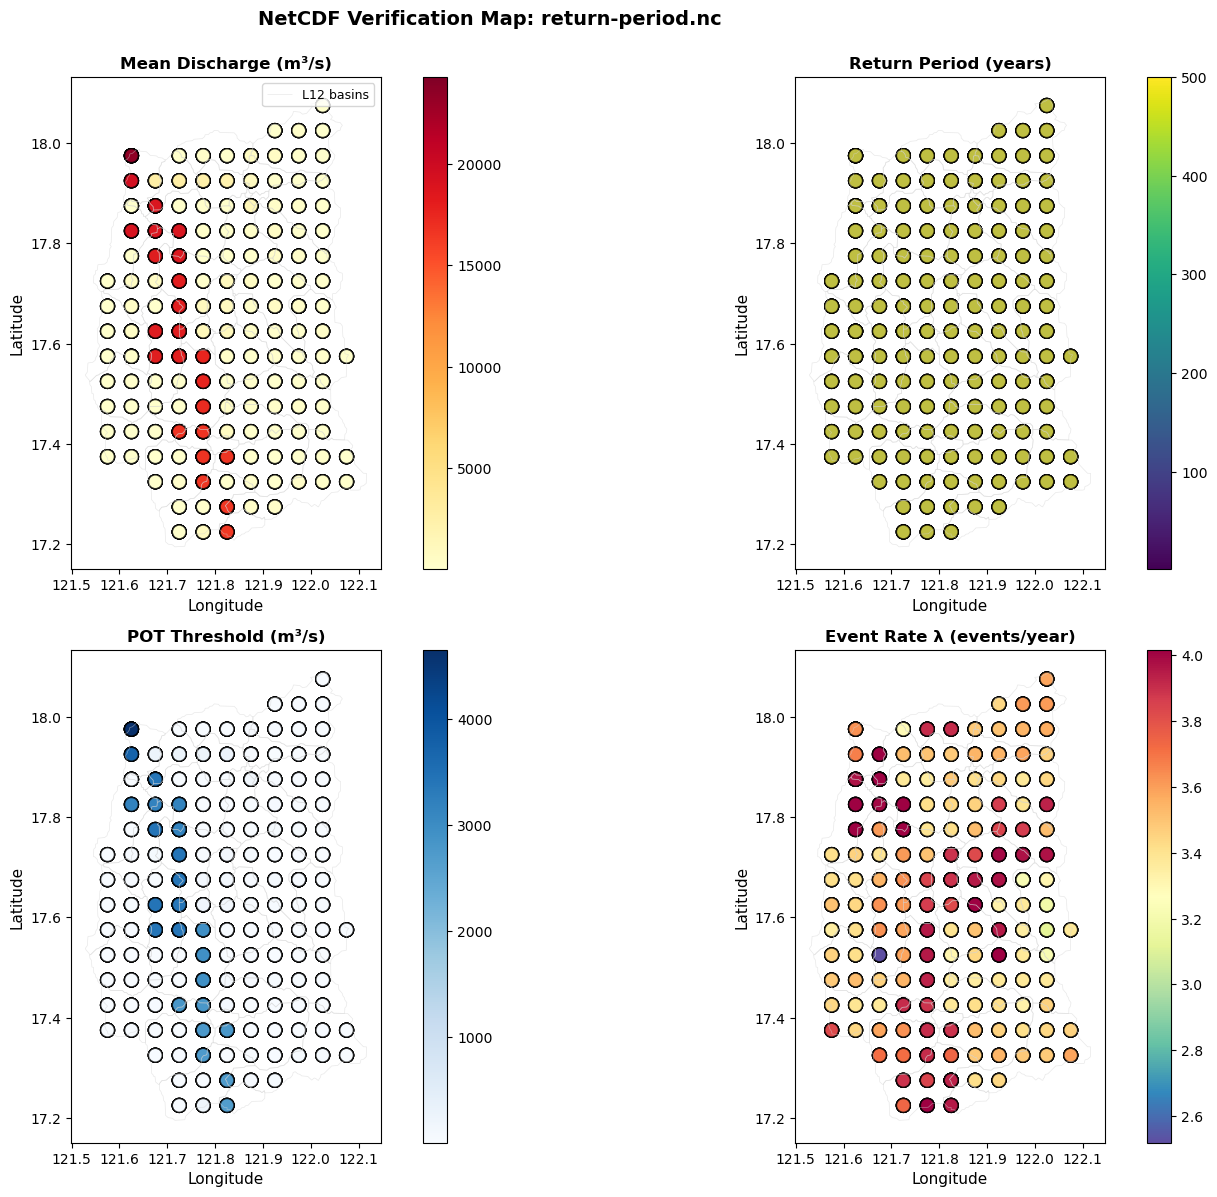

✓ ✓ Map saved: netcdf_verification_map.png
• Data Quality Checks:

✓ All gauges have coordinates: True
✓ All gauges have discharge values: True
✓ All gauges have return periods: True
✓ No duplicate gauges: False
✓ Thresholds populated: 1539/1539
✓ Lambda values populated: 1539/1539
✓ Section 13B complete: NetCDF verified and mapped ✓


In [33]:
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import numpy as np

log.section("SECTION 13B: Verify NetCDF Contents & Map")

netcdf_path = out_root / "return-period.nc"

# --- 1) Load and inspect NetCDF ---
log.step("Loading NetCDF file...")
ds = xr.open_dataset(netcdf_path, engine='netcdf4')

log.table("NetCDF File Contents", {
    "File": netcdf_path.name,
    "Dimensions": ", ".join(f"{k}={v}" for k, v in dict(ds.dims).items()),
    "Variables": ", ".join(ds.data_vars),
    "Coordinates": ", ".join(ds.coords),
    "Global attributes": len(ds.attrs),
})

log.step("NetCDF Global Attributes:")
for key, val in ds.attrs.items():
    print(f"  {key}: {val}")

# --- 2) Preview data ---
log.step("Data Preview:")
print(f"\nGauges: {len(ds['gauge'].values)}")
print(f"Latitude range: {float(ds['latitude'].min()):.4f}° to {float(ds['latitude'].max()):.4f}°")
print(f"Longitude range: {float(ds['longitude'].min()):.4f}° to {float(ds['longitude'].max()):.4f}°")
print(f"Discharge range: {float(ds['discharge_m3s'].min()):.1f} to {float(ds['discharge_m3s'].max()):.1f} m³/s")
print(f"Return period range: {float(ds['return_period'].min()):.1f} to {float(ds['return_period'].max()):.1f} years")

if 'threshold_m3s' in ds.data_vars:
    print(f"Threshold range: {float(ds['threshold_m3s'].min()):.1f} to {float(ds['threshold_m3s'].max()):.1f} m³/s")
if 'lambda_events_per_year' in ds.data_vars:
    print(f"Lambda range: {float(ds['lambda_events_per_year'].min()):.3f} to {float(ds['lambda_events_per_year'].max()):.3f} events/year")

# --- 3) Create GeoDataFrame for mapping ---
log.step("Creating map visualization...")

# Reshape data for 2D discharge array (gauge, return_period)
# Create one row per gauge×return_period combination
gdf_data = []

for gid_idx, gid in enumerate(ds['gauge'].values):
    lat = float(ds['latitude'].values[gid_idx])
    lon = float(ds['longitude'].values[gid_idx])
    threshold = float(ds['threshold_m3s'].values[gid_idx]) if 'threshold_m3s' in ds.data_vars else None
    lambda_val = float(ds['lambda_events_per_year'].values[gid_idx]) if 'lambda_events_per_year' in ds.data_vars else None
    
    # Get discharge values for this gauge across all return periods
    discharges = ds['discharge_m3s'].values[gid_idx, :]  # (9,) array for this gauge
    rps = ds['return_period'].values  # (9,) array of return periods
    
    for rp_idx, (rp, discharge) in enumerate(zip(rps, discharges)):
        gdf_data.append({
            'gauge_id': str(gid),
            'return_period': float(rp),
            'discharge_m3s': float(discharge),
            'latitude': lat,
            'longitude': lon,
            'threshold_m3s': threshold,
            'lambda_events_per_year': lambda_val,
            'geometry': Point(lon, lat)
        })

gdf = gpd.GeoDataFrame(gdf_data, crs="EPSG:4326")

log.success(f"Loaded {len(gdf)} gauge×return_period combinations from NetCDF")

# --- 4) Map visualization ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Map 1: Discharge levels
ax = axes[0, 0]
if 'selected_l12' in globals():
    selected_l12.boundary.plot(ax=ax, linewidth=0.5, color="lightgray", alpha=0.5, label="L12 basins")
gdf.plot(ax=ax, column='discharge_m3s', cmap='YlOrRd', markersize=100, 
         legend=True, alpha=0.7, edgecolor='black', linewidth=1)
ax.set_title("Mean Discharge (m³/s)", fontsize=12, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc='upper right', fontsize=9)

# Map 2: Return periods
ax = axes[0, 1]
if 'selected_l12' in globals():
    selected_l12.boundary.plot(ax=ax, linewidth=0.5, color="lightgray", alpha=0.5)
gdf.plot(ax=ax, column='return_period', cmap='viridis', markersize=100, 
         legend=True, alpha=0.7, edgecolor='black', linewidth=1)
ax.set_title("Return Period (years)", fontsize=12, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Map 3: Threshold levels
ax = axes[1, 0]
if 'selected_l12' in globals():
    selected_l12.boundary.plot(ax=ax, linewidth=0.5, color="lightgray", alpha=0.5)
gdf.plot(ax=ax, column='threshold_m3s', cmap='Blues', markersize=100, 
         legend=True, alpha=0.7, edgecolor='black', linewidth=1)
ax.set_title("POT Threshold (m³/s)", fontsize=12, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Map 4: Event rate (lambda)
ax = axes[1, 1]
if 'selected_l12' in globals():
    selected_l12.boundary.plot(ax=ax, linewidth=0.5, color="lightgray", alpha=0.5)
gdf.plot(ax=ax, column='lambda_events_per_year', cmap='Spectral_r', markersize=100, 
         legend=True, alpha=0.7, edgecolor='black', linewidth=1)
ax.set_title("Event Rate λ (events/year)", fontsize=12, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.suptitle(f"NetCDF Verification Map: {netcdf_path.name}", fontsize=14, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()

map_path = fig_dir / "netcdf_verification_map.png"
fig.savefig(map_path, dpi=300, bbox_inches="tight")
plt.close()

log.success(f"✓ Map saved: {map_path.name}")

# --- 5) Data quality checks ---
log.step("Data Quality Checks:")
print(f"\n✓ All gauges have coordinates: {gdf['geometry'].notna().all()}")
print(f"✓ All gauges have discharge values: {gdf['discharge_m3s'].notna().all()}")
print(f"✓ All gauges have return periods: {gdf['return_period'].notna().all()}")
print(f"✓ No duplicate gauges: {len(gdf) == len(gdf['gauge_id'].unique())}")
print(f"✓ Thresholds populated: {gdf['threshold_m3s'].notna().sum()}/{len(gdf)}")
print(f"✓ Lambda values populated: {gdf['lambda_events_per_year'].notna().sum()}/{len(gdf)}")

ds.close()
gc.collect()

log.success("Section 13B complete: NetCDF verified and mapped ✓")